In [414]:
import pandas as pd
from Functions import *
from Telescope import *

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.lines import Line2D
import seaborn as sns
from matplotlib import colors

from matplotlib.animation import FuncAnimation

import itertools

In [415]:
dirname = "/Users/ben_coull-neveu/Dropbox/- School -/Ariel Summer Internship 2024/Ariel Phase Curve and Transit Plots"

In [416]:
print(target_lists)

/Users/ben_coull-neveu/Dropbox/- School -/Ariel Summer Internship 2024/EXOECHO_PACKAGE/ExoEcho/src/ExoEcho/target_lists/


In [417]:
# Opening the target lists
tpcs = pd.read_csv(f"{target_lists}Ariel_MCS_TPCs_2024-07-09.csv")
known = pd.read_csv(f"{target_lists}Ariel_MCS_Known_2024-07-09.csv")

# adding column to identify if target is known or TPC
known["Known"] = True
tpcs["Known"] = False

# renaming the column to match the known targets. Not sure why they are different, but this seems to be the case for all Billy Edwards' target lists
tpcs.rename(columns={"Transit Duration [hr]" : "Transit Duration [hrs]"}, inplace=True)

# concatenate the Known and Tess Planetary Candidates (TPCs)
combined = pd.concat([known, tpcs])

# removing unnamed columns (comment the line out to see what I mean)
combined = combined.loc[:, ~combined.columns.str.contains('^Unnamed')]

print(combined.shape[0], "targets")
combined.head()

2747 targets


,Star Name,Star Mass [Ms],Star Mass Error Lower [Ms],Star Mass Error Upper [Ms],Star Temperature [K],Star Temperature Error Lower [K],Star Temperature Error Upper [K],Star Radius [Rs],Star Radius Error Lower [Rs],Star Radius Error Upper [Rs],...,TFOP SG5,Alerted,Updated,Public Comment,Sectors,FP_Flag,EB,VS,NASA PC,Star T Mag
0,WASP-43,0.69,-0.04,0.04,4500.0,-100.0,100.0,0.65,-0.01,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WASP-47,1.11,-0.49,0.89,5576.0,-68.0,68.0,1.16,-0.26,0.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TOI-5704,0.73,-0.08,0.08,4590.0,-126.0,126.0,0.76,-0.06,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TOI-672,0.54,-0.02,0.02,3765.0,-65.0,65.0,0.54,-0.02,0.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TOI-199,0.94,-0.01,0.00,5255.0,-10.0,12.0,0.82,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [418]:
# save combined csv
combined.to_csv(f"{target_lists}Ariel_MCS_Combined_2024-07-09.csv", index=False)

In [419]:
# setting the target list. This isn't particularly important; it just opens all the telescopes using that target list to allow the code to run faster.
# This can be done afterwards too, as in this case where we are creating the telescope objects after importing the Ariel module.

setTargetList("Ariel_MCS_Combined_2024-07-09")
import Ariel

In [420]:
# # Building the telescope objects using the combined target list. 
# # Be prepared for a long runtime!
# Ariel.constructArielInstruments("Ariel_MCS_Combined_2024-07-09")

In [421]:
# Ariel.insturments is a nested dictionary containing all the telescope objects.
Ariel.instruments

{'Ariel': {'Ariel_MCS_Combined_2024-07-09': {'Ariel AIRS CH0 1.95-3.9um D=1 R=100 tau=0.18': <Telescope.Telescope at 0x14c67ca90>,
   'Ariel AIRS CH0 1.95-3.9um D=1 R=3 tau=0.18': <Telescope.Telescope at 0x14c689050>,
   'Ariel AIRS CH0 1.95-3.9um D=1 R=50 tau=0.18': <Telescope.Telescope at 0x14cf01450>,
   'Ariel AIRS CH1 3.9-7.8um D=1 R=1 tau=0.18': <Telescope.Telescope at 0x14ce18e90>,
   'Ariel AIRS CH1 3.9-7.8um D=1 R=10 tau=0.18': <Telescope.Telescope at 0x14c624790>,
   'Ariel AIRS CH1 3.9-7.8um D=1 R=30 tau=0.18': <Telescope.Telescope at 0x14d2034d0>,
   'Ariel FGS1 0.6-0.8um D=1 R=1 tau=0.17': <Telescope.Telescope at 0x14d260d90>,
   'Ariel FGS2 0.8-1.1um D=1 R=1 tau=0.25': <Telescope.Telescope at 0x14d4dab10>,
   'Ariel NIRSpec 1.1-1.95um D=1 R=1 tau=0.27': <Telescope.Telescope at 0x14cebaad0>,
   'Ariel NIRSpec 1.1-1.95um D=1 R=10 tau=0.27': <Telescope.Telescope at 0x14d4af190>,
   'Ariel NIRSpec 1.1-1.95um D=1 R=20 tau=0.27': <Telescope.Telescope at 0x14d7cc190>,
   'Ariel 

In [422]:
# # Building the observation table. This is the main table that will be used to schedule observations.
# # again, this will take a while to run. Get a coffee or something while waiting.
# Ariel.constructObservationTable("Ariel_MCS_Combined_2024-07-09")

Plotting using data directly from Billy Edwards' target lists


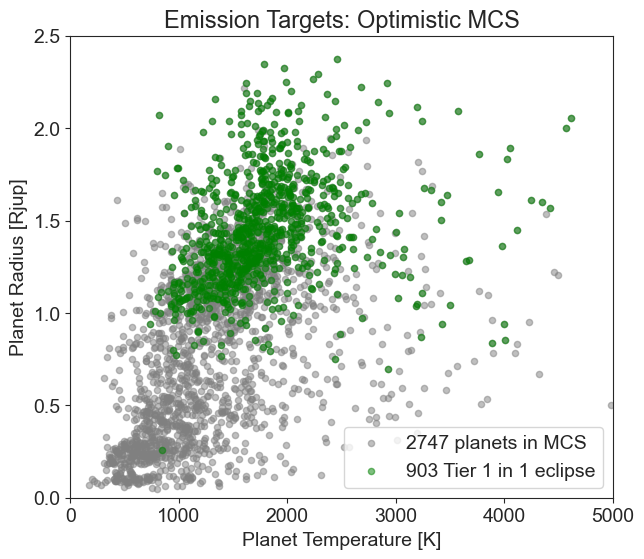

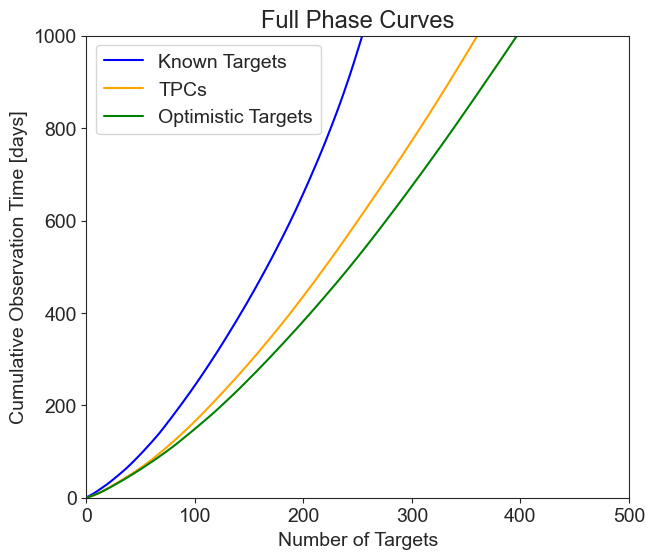

In [423]:
# Plotting using data directly from Billy Edwards' target lists

print("Plotting using data directly from Billy Edwards' target lists")

tier1 = combined[combined["Tier 1 Eclipses"] == 1]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(combined["Planet Temperature [K]"], combined["Planet Radius [Rjup]"], color='grey', s=20, alpha=0.5, label=f"{combined.shape[0]} planets in MCS")
ax.scatter(tier1["Planet Temperature [K]"], tier1["Planet Radius [Rjup]"], color='green', s=20, alpha=0.5, label=f"{tier1.shape[0]} Tier 1 in 1 eclipse")

fontsize=14
ax.legend(fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel("Planet Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Planet Radius [Rjup]", fontsize=fontsize)
ax.set_title("Emission Targets: Optimistic MCS", fontsize=fontsize+3)

ax.set_ylim(0,2.5)
ax.set_xlim(0,5000)
plt.show()

# set the observation time for each target to be the number of eclipses to achieve Tier 1 ESM quality multiplies by a full orbit + 3 transit durations (for full phase curve)
combined["Time to Tier 1 ESM PC [days]"] = (combined["Planet Period [days]"] + 3*combined["Transit Duration [hrs]"]/24) * combined["Tier 1 Eclipses"]


sorted = combined.sort_values(by="Time to Tier 1 ESM PC [days]", ascending=True)

sorted_known = sorted[sorted["Known"]]
sorted_tpc = sorted[~sorted["Known"]]

sorted.reset_index(inplace=True)
sorted_known.reset_index(inplace=True)
sorted_tpc.reset_index(inplace=True)

sorted["Cum Time to Tier 1 ESM PC [days]"] = sorted["Time to Tier 1 ESM PC [days]"].cumsum()
sorted_known["Cum Time to Tier 1 ESM PC [days]"] = sorted_known["Time to Tier 1 ESM PC [days]"].cumsum()
sorted_tpc["Cum Time to Tier 1 ESM PC [days]"] = sorted_tpc["Time to Tier 1 ESM PC [days]"].cumsum()



fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(sorted_known.index, sorted_known["Cum Time to Tier 1 ESM PC [days]"], color='blue', label="Known Targets")
ax.plot(sorted_tpc.index, sorted_tpc["Cum Time to Tier 1 ESM PC [days]"], color='orange', label="TPCs")
ax.plot(sorted.index, sorted["Cum Time to Tier 1 ESM PC [days]"], color='green', label="Optimistic Targets") 

ax.set_ylim(0, 1000)
ax.set_xlim(0, 500)

fontsize=14
ax.legend(fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel("Number of Targets", fontsize=fontsize)
ax.set_ylabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_title("Full Phase Curves", fontsize=fontsize+3)

plt.show()

Plotting using the Ariel module


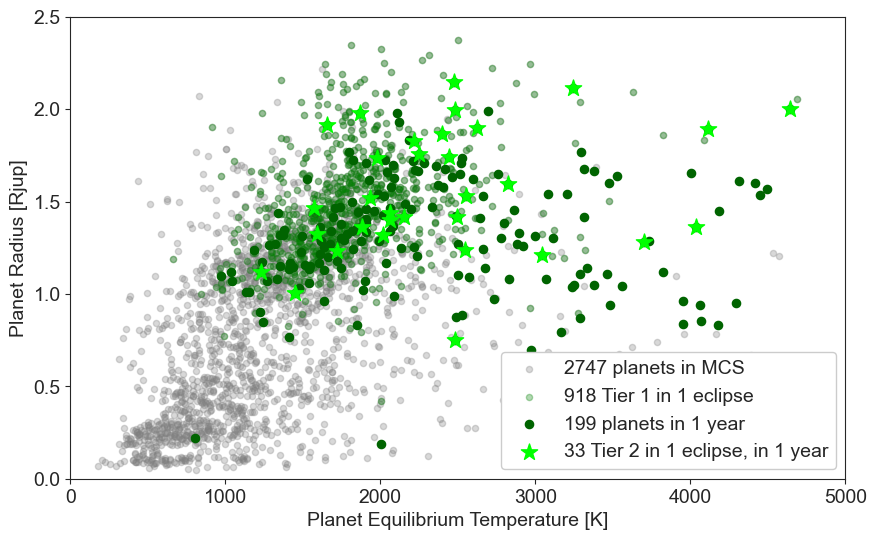

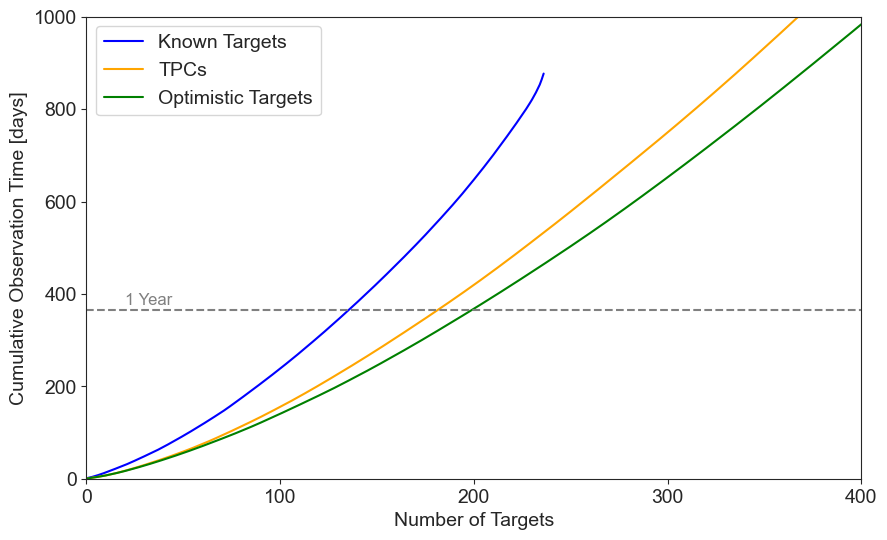

In [424]:
# Plotting using data from the Ariel module

print("Plotting using the Ariel module")

obsdf = Ariel.getObservationTable("Ariel_MCS_Combined_2024-07-09")

obsdf["log Tier 1 ESM"] = np.log10(obsdf["Tier 1 ESM"])

tier1 = obsdf[obsdf["Tier 1 Observations ESM"] == 1]

# set the observation time for each target to be the number of eclipses to achieve Tier 1 ESM quality multiplies by a full orbit + 3 transit durations (for full phase curve)
tier1["Time to Tier 1 ESM PC [days]"] = (tier1["Planet Period [days]"] + 3*tier1["Transit Duration [hrs]"]/24) * tier1["Tier 1 Observations ESM"]
sorted = tier1.sort_values(by="Time to Tier 1 ESM PC [days]", ascending=True)

sorted_known = sorted[sorted["Known"]]
sorted_tpc = sorted[~sorted["Known"]]

sorted.reset_index(inplace=True)
sorted_known.reset_index(inplace=True)
sorted_tpc.reset_index(inplace=True)

sorted["Cum Time to Tier 1 ESM PC [days]"] = sorted["Time to Tier 1 ESM PC [days]"].cumsum()
sorted_known["Cum Time to Tier 1 ESM PC [days]"] = sorted_known["Time to Tier 1 ESM PC [days]"].cumsum()
sorted_tpc["Cum Time to Tier 1 ESM PC [days]"] = sorted_tpc["Time to Tier 1 ESM PC [days]"].cumsum()

sorted1yr = sorted[sorted["Cum Time to Tier 1 ESM PC [days]"] < 365]
sorted1yr.shape[0]

sorted1yr_tier2 = sorted1yr[sorted1yr["Tier 2 Observations ESM"] == 1]
sorted1yr_tier2.shape[0]




fig, ax = plt.subplots(figsize=(10, 6))

# ax.scatter(obsdf["Planet Temperature [K]"], obsdf["Planet Radius [Rjup]"], color='grey', s=20, alpha=0.3, label=f"{obsdf.shape[0]} planets in MCS")
ax.scatter(obsdf["Dayside Emitting Temperature [K]"], obsdf["Planet Radius [Rjup]"], color='grey', s=20, alpha=0.3, label=f"{obsdf.shape[0]} planets in MCS")
ax.scatter(tier1["Dayside Emitting Temperature [K]"], tier1["Planet Radius [Rjup]"], color='green', s=20, alpha=0.3, label=f"{tier1.shape[0]} Tier 1 in 1 eclipse")
ax.scatter(sorted1yr["Dayside Emitting Temperature [K]"], sorted1yr["Planet Radius [Rjup]"], color='darkgreen', s=35, alpha=1, label=f"{sorted1yr.shape[0]} planets in 1 year")
ax.scatter(sorted1yr_tier2["Dayside Emitting Temperature [K]"], sorted1yr_tier2["Planet Radius [Rjup]"], color='lime', marker='*', s=150, alpha=1, label=f"{sorted1yr_tier2.shape[0]} Tier 2 in 1 eclipse, in 1 year")

fontsize=14
ax.legend(fontsize=fontsize, framealpha=1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel("Planet Equilibrium Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Planet Radius [Rjup]", fontsize=fontsize)
# ax.set_title("Emission Targets: Optimistic MCS", fontsize=fontsize+3)


ax.set_ylim(0,2.5)
ax.set_xlim(0,5000)
plt.show()





fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sorted_known.index, sorted_known["Cum Time to Tier 1 ESM PC [days]"], color='blue', label="Known Targets")
ax.plot(sorted_tpc.index, sorted_tpc["Cum Time to Tier 1 ESM PC [days]"], color='orange', label="TPCs")
ax.plot(sorted.index, sorted["Cum Time to Tier 1 ESM PC [days]"], color='green', label="Optimistic Targets") 

ax.set_ylim(0, 1000)
ax.set_xlim(0, 400)

ax.set_xticks([0, 100, 200, 300, 400])

ax.axhline(365, color='grey', linestyle='--')
ax.text(20, 370, "1 Year", fontsize=12, color='grey', ha='left', va='bottom')


fontsize=14
ax.legend(fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel("Number of Targets", fontsize=fontsize)
ax.set_ylabel("Cumulative Observation Time [days]", fontsize=fontsize)
# ax.set_title("Full Phase Curves", fontsize=fontsize+3)

plt.show()

Plotting using the Ariel module


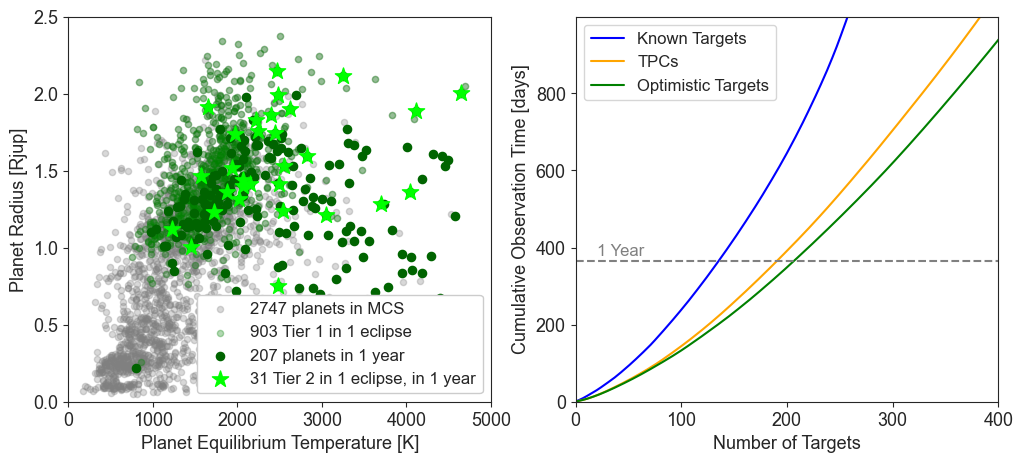

In [425]:
# Plotting using data from the Ariel module

print("Plotting using the Ariel module")

obsdf = Ariel.getObservationTable("Ariel_MCS_Combined_2024-07-09")

obsdf["log Tier 1 ESM"] = np.log10(obsdf["Tier 1 ESM"])

tier1 = obsdf[obsdf["Tier 1 Eclipses"] == 1]

# set the observation time for each target to be the number of eclipses to achieve Tier 1 ESM quality multiplies by a full orbit + 3 transit durations (for full phase curve)
obsdf["Time to Tier 1 ESM PC [days]"] = (obsdf["Planet Period [days]"] + 3*obsdf["Transit Duration [hrs]"]/24) * obsdf["Tier 1 Observations ESM"]
sorted = obsdf.sort_values(by="Time to Tier 1 ESM PC [days]", ascending=True)

sorted_known = sorted[sorted["Known"]]
sorted_tpc = sorted[~sorted["Known"]]

sorted.reset_index(inplace=True)
sorted_known.reset_index(inplace=True)
sorted_tpc.reset_index(inplace=True)

sorted["Cum Time to Tier 1 ESM PC [days]"] = sorted["Time to Tier 1 ESM PC [days]"].cumsum()
sorted_known["Cum Time to Tier 1 ESM PC [days]"] = sorted_known["Time to Tier 1 ESM PC [days]"].cumsum()
sorted_tpc["Cum Time to Tier 1 ESM PC [days]"] = sorted_tpc["Time to Tier 1 ESM PC [days]"].cumsum()

sorted1yr = sorted[sorted["Cum Time to Tier 1 ESM PC [days]"] < 365]
sorted1yr.shape[0]

sorted1yr_tier2 = sorted1yr[sorted1yr["Tier 2 Observations ESM"] == 1]
sorted1yr_tier2.shape[0]




fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax, ax1 = axs

# ax.scatter(obsdf["Planet Temperature [K]"], obsdf["Planet Radius [Rjup]"], color='grey', s=20, alpha=0.3, label=f"{obsdf.shape[0]} planets in MCS")
ax.scatter(obsdf["Dayside Emitting Temperature [K]"], obsdf["Planet Radius [Rjup]"], color='grey', s=20, alpha=0.3, label=f"{obsdf.shape[0]} planets in MCS")
ax.scatter(tier1["Dayside Emitting Temperature [K]"], tier1["Planet Radius [Rjup]"], color='green', s=20, alpha=0.3, label=f"{tier1.shape[0]} Tier 1 in 1 eclipse")
ax.scatter(sorted1yr["Dayside Emitting Temperature [K]"], sorted1yr["Planet Radius [Rjup]"], color='darkgreen', s=35, alpha=1, label=f"{sorted1yr.shape[0]} planets in 1 year")
ax.scatter(sorted1yr_tier2["Dayside Emitting Temperature [K]"], sorted1yr_tier2["Planet Radius [Rjup]"], color='lime', marker='*', s=150, alpha=1, label=f"{sorted1yr_tier2.shape[0]} Tier 2 in 1 eclipse, in 1 year")

fontsize=13
ax.legend(fontsize=fontsize-1, framealpha=1)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel("Planet Equilibrium Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Planet Radius [Rjup]", fontsize=fontsize)
# ax.set_title("Emission Targets: Optimistic MCS", fontsize=fontsize+3)


ax.set_ylim(0,2.5)
ax.set_xlim(0,5000)
# plt.show()





# fig, ax = plt.subplots(figsize=(10, 6))

ax1.plot(sorted_known.index, sorted_known["Cum Time to Tier 1 ESM PC [days]"], color='blue', label="Known Targets")
ax1.plot(sorted_tpc.index, sorted_tpc["Cum Time to Tier 1 ESM PC [days]"], color='orange', label="TPCs")
ax1.plot(sorted.index, sorted["Cum Time to Tier 1 ESM PC [days]"], color='green', label="Optimistic Targets") 

ax1.set_ylim(0, 999)
ax1.set_xlim(0, 400)

ax1.set_xticks([0, 100, 200, 300, 400])

ax1.axhline(365, color='grey', linestyle='--')
ax1.text(20, 370, "1 Year", fontsize=12, color='grey', ha='left', va='bottom')


# fontsize=14
ax1.legend(fontsize=fontsize-1)
ax1.tick_params(axis='both', which='major', labelsize=fontsize)
ax1.set_xlabel("Number of Targets", fontsize=fontsize)
ax1.set_ylabel("Cumulative Observation Time [days]", fontsize=fontsize)
# ax.set_title("Full Phase Curves", fontsize=fontsize+3)

plt.show()

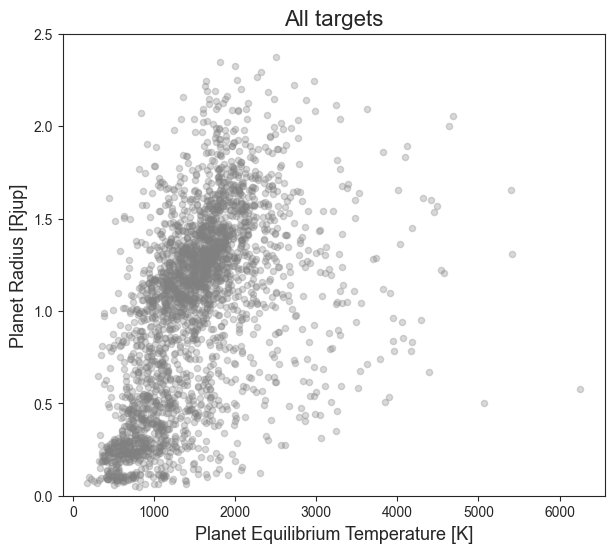

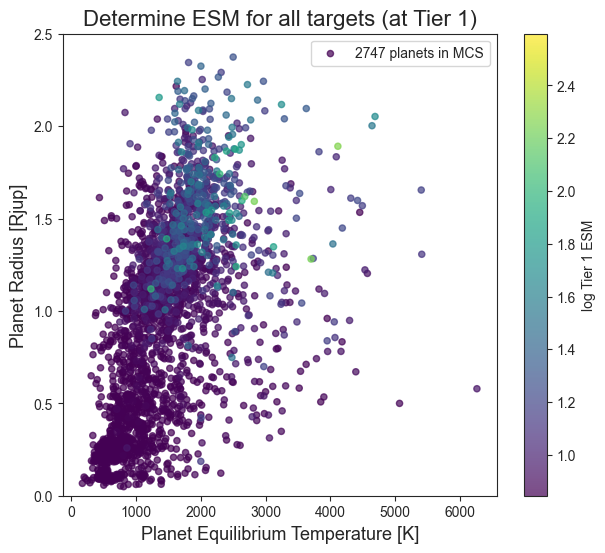

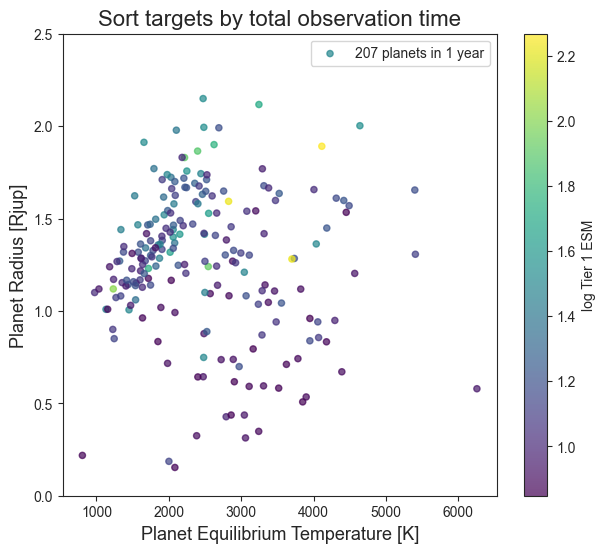

In [426]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(obsdf["Dayside Emitting Temperature [K]"], obsdf["Planet Radius [Rjup]"], color='grey', s=20, alpha=0.3, label=f"{obsdf.shape[0]} Tier 1 in 1 eclipse")

ax.set_xlabel("Planet Equilibrium Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Planet Radius [Rjup]", fontsize=fontsize)
ax.set_title("All targets", fontsize=fontsize+3)
ax.set_ylim(0,2.5)

plt.show()


fig, ax = plt.subplots(figsize=(7, 6))

obsdf = obsdf.sort_values(by="Tier 1 ESM")
obsdf.plot("Dayside Emitting Temperature [K]", "Planet Radius [Rjup]", c="log Tier 1 ESM", ax=ax, kind='scatter', cmap="viridis", s=20, alpha=0.7, label=f"{obsdf.shape[0]} planets in MCS")
# ax.scatter(tier1["Dayside Emitting Temperature [K]"], tier1["Planet Radius [Rjup]"], color='green', s=20, alpha=0.3, label=f"{tier1.shape[0]} Tier 1 in 1 eclipse")
# plt.colorbar( cax=cax, label="Tier 1 ESM")
# fontsize=14
# ax.legend(fontsize=fontsize)

ax.set_xlabel("Planet Equilibrium Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Planet Radius [Rjup]", fontsize=fontsize)
ax.set_title("Determine ESM for all targets (at Tier 1)", fontsize=fontsize+3)
ax.set_ylim(0,2.5)
plt.show()


fig, ax = plt.subplots(figsize=(7, 6))

sorted1yr.plot("Dayside Emitting Temperature [K]", "Planet Radius [Rjup]", c="log Tier 1 ESM", ax=ax, kind='scatter', cmap="viridis", s=20, alpha=0.7, label=f"{sorted1yr.shape[0]} planets in 1 year")
ax.set_xlabel("Planet Equilibrium Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Planet Radius [Rjup]", fontsize=fontsize)
ax.set_title("Sort targets by total observation time", fontsize=fontsize+3)
ax.set_ylim(0,2.5)
plt.show()

In [427]:
sorted1yr[(sorted1yr["Planet Radius [Rjup]"] < 0.3) &
          (sorted1yr["Dayside Emitting Temperature [K]"] < 1500)]

# sorted1yr[sorted1yr["Star Name"] ==  "TOI-3059"]["Tier 1 Observations ESM"]

,index,Star Name,Star Mass [Ms],Star Mass Error Lower [Ms],Star Mass Error Upper [Ms],Star Temperature [K],Star Temperature Error Lower [K],Star Temperature Error Upper [K],Star Radius [Rs],Star Radius Error Lower [Rs],...,Tier 2 Full Phase Curve SNR,Tier 3 Observations ESM,Tier 3 ESM,Tier 3 Observations TSM,Tier 3 TSM,Tier 3 Observations Full Phase Curve SNR,Tier 3 Full Phase Curve SNR,log Tier 1 ESM,Time to Tier 1 ESM PC [days],Cum Time to Tier 1 ESM PC [days]
97,1215,TOI-3059,0.4004,NaN,NaN,3301.0,-51.7,51.7,0.445818,NaN,...,10.337253,42.0,7.022224,1.0,7.970318,18.0,10.247515,0.860023,1.744722,127.650911


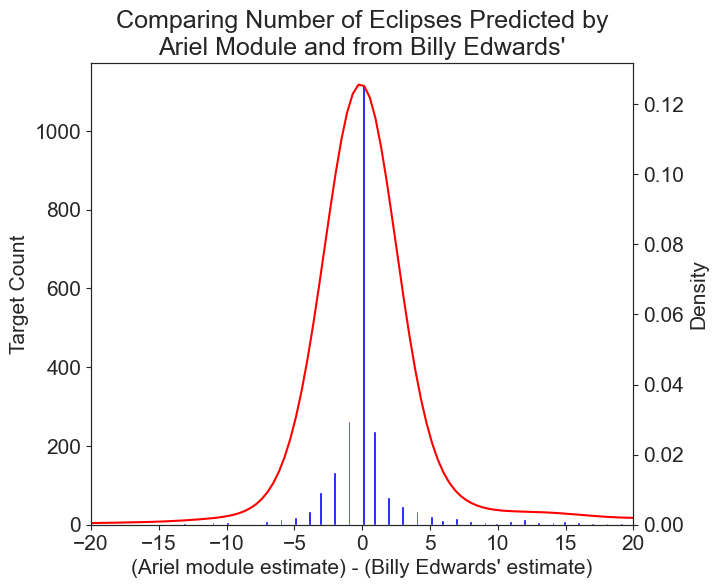

In [428]:
# Comparing to billy edwards' estimates

obsdf["esm tier 1 diff"] = obsdf["Tier 1 Observations ESM"] - obsdf["Tier 1 Eclipses"]

fig, ax = plt.subplots(figsize=(7, 6))

cutdf = obsdf[obsdf["Tier 1 Eclipses"] < 100]

cutdf["esm tier 1 diff"].plot.hist(bins=1000, ax=ax, color='blue', alpha=1)


ax1 = ax.twinx()
cutdf["esm tier 1 diff"].plot.kde(ax=ax1, c='red')
ax1.set_ylim(0)

ax.set_xlim(-20, 20)

fontsize = 15
ax.set_ylabel("Target Count", fontsize=fontsize)
ax.set_xlabel("(Ariel module estimate) - (Billy Edwards' estimate)", fontsize=fontsize)
ax1.set_ylabel("Density", fontsize=fontsize)
ax.set_title("Comparing Number of Eclipses Predicted by\nAriel Module and from Billy Edwards'", fontsize=fontsize+3)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax1.tick_params(axis='y', which='major', labelsize=fontsize)

plt.show()

In [429]:
Ariel.instruments

{'Ariel': {'Ariel_MCS_Combined_2024-07-09': {'Ariel AIRS CH0 1.95-3.9um D=1 R=100 tau=0.18': <Telescope.Telescope at 0x14c67ca90>,
   'Ariel AIRS CH0 1.95-3.9um D=1 R=3 tau=0.18': <Telescope.Telescope at 0x14c689050>,
   'Ariel AIRS CH0 1.95-3.9um D=1 R=50 tau=0.18': <Telescope.Telescope at 0x14cf01450>,
   'Ariel AIRS CH1 3.9-7.8um D=1 R=1 tau=0.18': <Telescope.Telescope at 0x14ce18e90>,
   'Ariel AIRS CH1 3.9-7.8um D=1 R=10 tau=0.18': <Telescope.Telescope at 0x14c624790>,
   'Ariel AIRS CH1 3.9-7.8um D=1 R=30 tau=0.18': <Telescope.Telescope at 0x14d2034d0>,
   'Ariel FGS1 0.6-0.8um D=1 R=1 tau=0.17': <Telescope.Telescope at 0x14d260d90>,
   'Ariel FGS2 0.8-1.1um D=1 R=1 tau=0.25': <Telescope.Telescope at 0x14d4dab10>,
   'Ariel NIRSpec 1.1-1.95um D=1 R=1 tau=0.27': <Telescope.Telescope at 0x14cebaad0>,
   'Ariel NIRSpec 1.1-1.95um D=1 R=10 tau=0.27': <Telescope.Telescope at 0x14d4af190>,
   'Ariel NIRSpec 1.1-1.95um D=1 R=20 tau=0.27': <Telescope.Telescope at 0x14d7cc190>,
   'Ariel 

In [430]:
obsdf["Time to Tier 1 TSM [days]"] = obsdf["Tier 1 Observations TSM"] * (3*obsdf["Transit Duration [hrs]"]/24)
obsdf["Time to Tier 2 TSM [days]"] = obsdf["Tier 2 Observations TSM"] * (3*obsdf["Transit Duration [hrs]"]/24)
obsdf["Time to Tier 3 TSM [days]"] = obsdf["Tier 3 Observations TSM"] * (3*obsdf["Transit Duration [hrs]"]/24)

# making cumulative plots for Nic

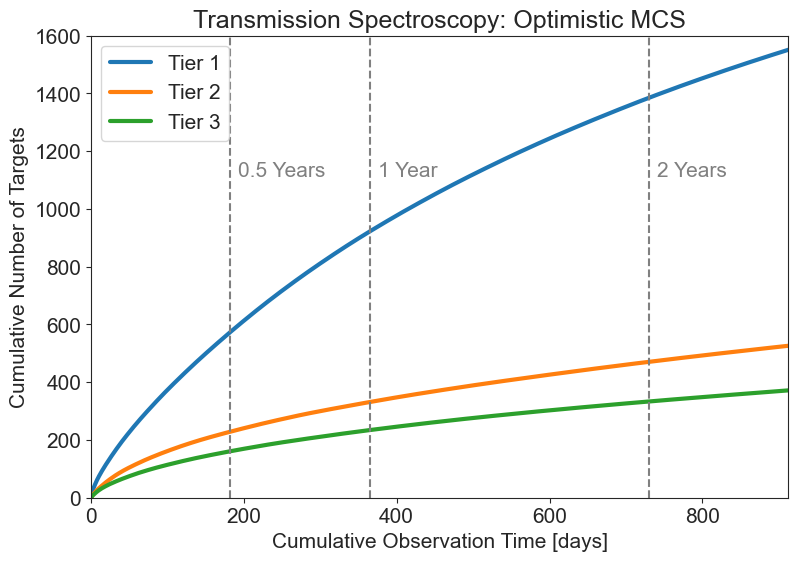

In [431]:
# transmission spectroscopy

fig, ax = plt.subplots(figsize=(9, 6))
plt.xlim(0, 2.5*365)
plt.ylim(0, 1600)

fontsize = 15

plt.title("Transmission Spectroscopy: Optimistic MCS", fontsize=fontsize+3)

sorted = obsdf
sorted = sorted[sorted["Transit Duration [hrs]"].notna()]

sorted.sort_values(by="Time to Tier 1 TSM [days]", ascending=True, inplace=True)
sorted.reset_index(inplace=True, drop=True)
sorted["Cumulative Time to Tier 1 TSM [days]"] = sorted["Time to Tier 1 TSM [days]"].cumsum()
plt.plot(sorted["Cumulative Time to Tier 1 TSM [days]"], sorted.index, linewidth=3, label="Tier 1")

sorted.sort_values(by="Time to Tier 2 TSM [days]", ascending=True, inplace=True)
sorted.reset_index(inplace=True, drop=True)
sorted["Cumulative Time to Tier 2 TSM [days]"] = sorted["Time to Tier 2 TSM [days]"].cumsum()
plt.plot(sorted["Cumulative Time to Tier 2 TSM [days]"], sorted.index, linewidth=3, label="Tier 2")

sorted.sort_values(by="Time to Tier 3 TSM [days]", ascending=True, inplace=True)
sorted.reset_index(inplace=True, drop=True)
sorted["Cumulative Time to Tier 3 TSM [days]"] = sorted["Time to Tier 3 TSM [days]"].cumsum()
plt.plot(sorted["Cumulative Time to Tier 3 TSM [days]"], sorted.index, linewidth=3, label="Tier 3")

plt.axvline(365/2, color='grey', linestyle='--')
plt.axvline(1*365, color='grey', linestyle='--')   
plt.axvline(2*365, color='grey', linestyle='--')
plt.text(365/2+10, 1100, "0.5 Years", fontsize=fontsize, color='grey', ha='left', va='bottom')
plt.text(1*365+10, 1100, "1 Year", fontsize=fontsize, color='grey', ha='left', va='bottom')
plt.text(2*365+10, 1100, "2 Years", fontsize=fontsize, color='grey', ha='left', va='bottom')

plt.xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
plt.ylabel("Cumulative Number of Targets", fontsize=fontsize)

plt.tick_params(axis='both', which='major', labelsize=fontsize)

plt.legend(fontsize=fontsize, loc='upper left')

plt.savefig(dirname + "/Transits/Plots/Transmission_Spectroscopy_Optimistic_MCS.png", dpi=300, bbox_inches='tight')
plt.show()

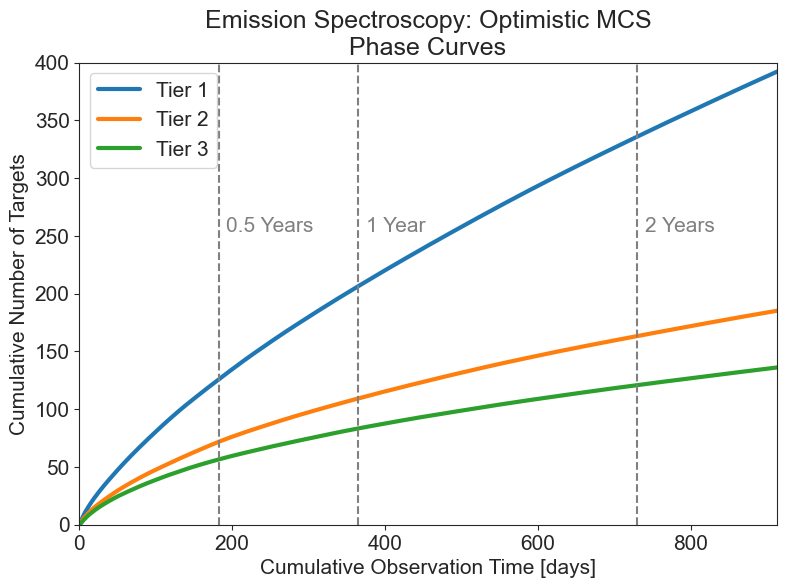

In [432]:
# phase curve spectroscopy

fig, ax = plt.subplots(figsize=(9, 6))
plt.xlim(0, 2.5*365)
plt.ylim(0, 400)

fontsize = 15

plt.title("Emission Spectroscopy: Optimistic MCS\nPhase Curves", fontsize=fontsize+3)

sorted = obsdf
sorted = sorted[sorted["Transit Duration [hrs]"].notna()]

sorted["Tier 1 eclipses Time to Tier 1 ESM PC [days]"] = sorted["Tier 1 Observations ESM"] * (sorted["Planet Period [days]"] + 3*sorted["Transit Duration [hrs]"]/24)
sorted.sort_values(by="Tier 1 eclipses Time to Tier 1 ESM PC [days]", ascending=True, inplace=True)
sorted.reset_index(inplace=True, drop=True)
sorted["Cumulative time tier 1 eclipses [days]"] = sorted["Tier 1 eclipses Time to Tier 1 ESM PC [days]"].cumsum()
plt.plot(sorted["Cumulative time tier 1 eclipses [days]"], sorted.index, linewidth=3, label="Tier 1")

sorted["Tier 2 eclipses Time to Tier 1 ESM PC [days]"] = sorted["Tier 2 Observations ESM"] * (sorted["Planet Period [days]"] + 3*sorted["Transit Duration [hrs]"]/24)
sorted.sort_values(by="Tier 2 eclipses Time to Tier 1 ESM PC [days]", ascending=True, inplace=True)
sorted.reset_index(inplace=True, drop=True)
sorted["Cumulative time tier 2 eclipses [days]"] = sorted["Tier 2 eclipses Time to Tier 1 ESM PC [days]"].cumsum()
plt.plot(sorted["Cumulative time tier 2 eclipses [days]"], sorted.index, linewidth=3, label="Tier 2")

sorted["Tier 3 eclipses Time to Tier 1 ESM PC [days]"] = sorted["Tier 3 Observations ESM"] * (sorted["Planet Period [days]"] + 3*sorted["Transit Duration [hrs]"]/24)
sorted.sort_values(by="Tier 3 eclipses Time to Tier 1 ESM PC [days]", ascending=True, inplace=True)
sorted.reset_index(inplace=True, drop=True)
sorted["Cumulative time tier 3 eclipses [days]"] = sorted["Tier 3 eclipses Time to Tier 1 ESM PC [days]"].cumsum()
plt.plot(sorted["Cumulative time tier 3 eclipses [days]"], sorted.index, linewidth=3, label="Tier 3")


plt.axvline(365/2, color='grey', linestyle='--')
plt.axvline(1*365, color='grey', linestyle='--')   
plt.axvline(2*365, color='grey', linestyle='--')
plt.text(365/2+10, 250, "0.5 Years", fontsize=fontsize, color='grey', ha='left', va='bottom')
plt.text(1*365+10, 250, "1 Year", fontsize=fontsize, color='grey', ha='left', va='bottom')
plt.text(2*365+10, 250, "2 Years", fontsize=fontsize, color='grey', ha='left', va='bottom')

plt.xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
plt.ylabel("Cumulative Number of Targets", fontsize=fontsize)

plt.tick_params(axis='both', which='major', labelsize=fontsize)
plt.legend(fontsize=fontsize, loc='upper left')
plt.savefig(dirname + "/Phase Curves/Plots/Emission_Spectroscopy_Optimistic_MCS.png", dpi=300, bbox_inches='tight')
plt.show()

# Balanced Bins

In [433]:
def create_multidimensional_bins(df, bin_config):
    """
    Create bins based on combinations of all parameters and generate DataFrames for each bin.

    Args:
        df (pd.DataFrame): The input DataFrame to be binned.
        bin_config (dict): Dictionary where keys are parameter names (df column names)
                           and values are the number of bins for each parameter.

    Returns:
        dict: A dictionary where keys are tuples representing bin indices for all parameters
              (e.g., (0, 0), (0, 1), ...), and values are DataFrames containing the targets
              for each bin.
    """
    # Step 1: Create bins for each parameter
    bin_columns = {}
    df_new = df.copy()
    for param, num_bins in bin_config.items():
        # Create equal-sized bins for the parameter
        df_new[f"{param}_bin"] = pd.qcut(df_new[param], q=num_bins, labels=False, duplicates="drop")
        bin_columns[param] = f"{param}_bin"

    # Step 2: Generate all combinations of bins
    bin_names = list(bin_columns.values())
    bin_combinations = list(itertools.product(*[range(bin_config[param]) for param in bin_config]))

    # Step 3: Create a DataFrame for each bin combination
    bin_dfs = {}
    for combination in bin_combinations:
        # Build the condition for this bin combination
        condition = pd.Series(True, index=df_new.index)
        for i, param in enumerate(bin_names):
            condition &= df_new[param] == combination[i]
        
        # Filter the DataFrame for this bin and store it
        bin_dfs[combination] = df_new[condition].copy()
    
    return bin_dfs


def round_robin_ordering_multidimensional(bin_dfs, sort_column='Time to Tier 2 TSM [hrs]', ascending=True):
    """
    Create an ordered DataFrame with all targets using a round-robin selection process
    based on multidimensional bins.

    Args:
        bin_dfs (dict): Dictionary of bin-specific DataFrames (keys are bin indices, values are DataFrames).
        sort_column (str): The column to sort each bin's DataFrame. Default is 'Time to Tier 2 TSM [hrs]'.
        ascending (bool): Whether to sort in ascending order. Default is False (descending).

    Returns:
        pd.DataFrame: An ordered DataFrame containing all targets.
    """
    # Step 1: Sort each bin-specific DataFrame
    sorted_bins = {}
    for bin_name, bin_df in bin_dfs.items():
        sorted_bins[bin_name] = bin_df.sort_values(by=sort_column, ascending=ascending).reset_index(drop=True)
    
    # Step 2: Round-robin selection
    result = []
    # print((len(bin_df) for bin_df in sorted_bins.values()))
    max_targets = max(len(bin_df) for bin_df in sorted_bins.values())  # Find the maximum size of any bin
    
    for i in range(max_targets):
        for bin_name, bin_df in sorted_bins.items():
            if i < len(bin_df):  # Only add if the current bin has more targets
                result.append(bin_df.iloc[i])
    
    # Step 3: Combine into a single DataFrame
    ordered_df = pd.DataFrame(result).reset_index(drop=True)
    return ordered_df

def create_balanced_bins(df, bin_config, sort_column='Time to Tier 2 TSM [hrs]', ascending=True, cumulative_sum_column='Time to Tier 2 TSM [hrs]'):
    bin_dfs = create_multidimensional_bins(df, bin_config)
    ordered_df = round_robin_ordering_multidimensional(bin_dfs, sort_column=sort_column, ascending=ascending)
    
    
    ordered_df[f"Cum Sum {cumulative_sum_column}"] = ordered_df[cumulative_sum_column].cumsum()
    
    
    ordered_df["bin_index"] = ordered_df.apply(lambda row: tuple(row[f'{col}_bin'] for col in bin_config.keys()), axis=1)
    
    
    bin_num = len(set(ordered_df["bin_index"]))
    ordered_df["empty_bins"] = ordered_df.apply(lambda x: bin_num - len(set(ordered_df["bin_index"].loc[x.name::])), axis=1)
    
    
    return ordered_df


# bins_df = create_multidimensional_bins(combined, bin_config)
# ordered_df = round_robin_ordering_multidimensional(bins_df)
# ordered_df["Cum Sum Time to T2 [days]"] = ordered_df["Time to Tier 2 TSM [hrs]"].cumsum()/24
# cumulative_counts = np.arange(1, len(ordered_df) + 1)

# Fixed Bins

In [434]:
def create_fixed_multimentional_bins(df, bin_config):
    """
    Create bins based on fixed values for each parameter and generate DataFrames for each bin.
    
    Args:
        df (pd.DataFrame): The input DataFrame to be binned.
        bin_config (dict): Dictionary where keys are parameter names (df column names)
                           and values are lists of bin edges for each parameter.

    Returns:
        dict: A dictionary where keys are tuples representing bin indices for all parameters
              (e.g., (0, 0), (0, 1), ...), and values are DataFrames containing the targets
              for each bin.
    """
    
    # Step 1: Create bins for each parameter
    bin_columns = {}
    df_new = df.copy()
    
    # force bin_config to include the minimum and maximum values of the parameter
    bin_config = bin_config.copy()
    for param in bin_config.keys():
        if df_new[param].min() < min(bin_config[param]):
            bin_config[param].insert(0, df_new[param].min())
        if df_new[param].max() > max(bin_config[param]):
            bin_config[param].append(df_new[param].max())
    
    for param, bins in bin_config.items():
        # Create bins for the parameter
        df_new[f"{param}_bin"] = pd.cut(df_new[param], bins=bins, labels=False, duplicates="drop")
        bin_columns[param] = f"{param}_bin"
        
    # Step 2: Generate all combinations of bins
    bin_names = list(bin_columns.values())
    bin_combinations = list(itertools.product(*[range(len(bin_config[param]) - 1) for param in bin_config]))
    
    # Step 3: Create a DataFrame for each bin combination
    bin_dfs = {}
    for combination in bin_combinations:
        # Build the condition for this bin combination
        condition = pd.Series(True, index=df_new.index)
        for i, param in enumerate(bin_names):
            condition &= df_new[param] == combination[i]
        
        # Filter the DataFrame for this bin and store it
        bin_dfs[combination] = df_new[condition].copy()
        
    return bin_dfs


def round_robin_ordering_fixed(bin_dfs, sort_column='Time to Tier 2 TSM [hrs]', ascending=True):
    """
    Create an ordered DataFrame with all targets using a round-robin selection process based on fixed bins.
    """
    # Step 1: Sort each bin-specific DataFrame
    sorted_bins = {}
    for bin_name, bin_df in bin_dfs.items():
        sorted_bins[bin_name] = bin_df.sort_values(by=sort_column, ascending=ascending).reset_index(drop=True)
        
    # Step 2: Round-robin selection
    result = []
    max_targets = max(len(bin_df) for bin_df in sorted_bins.values())  # Find the maximum size of any bin
    
    for i in range(max_targets):
        for bin_name, bin_df in sorted_bins.items():
            if i < len(bin_df):  # Only add if the current bin has more targets
                result.append(bin_df.iloc[i])
                
    # Step 3: Combine into a single DataFrame
    ordered_df = pd.DataFrame(result).reset_index(drop=True)
    return ordered_df


def create_fixed_bins(df, bin_config, sort_column='Time to Tier 2 TSM [hrs]', ascending=True, time_column='Time to Tier 2 TSM [hrs]'):
    bin_dfs = create_fixed_multimentional_bins(df, bin_config)
    ordered_df = round_robin_ordering_fixed(bin_dfs, sort_column=sort_column, ascending=ascending)
    
    ordered_df[f"Cum Sum {time_column}"] = ordered_df[time_column].cumsum()
    
    ordered_df["bin_index"] = ordered_df.apply(lambda row: tuple(row[f'{col}_bin'] for col in bin_config.keys()), axis=1)
    
    bin_num = len(set(ordered_df["bin_index"]))
    ordered_df["empty_bins"] = ordered_df.apply(lambda x: bin_num - len(set(ordered_df["bin_index"].loc[x.name::])), axis=1)
    
    return ordered_df

# Adding bins:

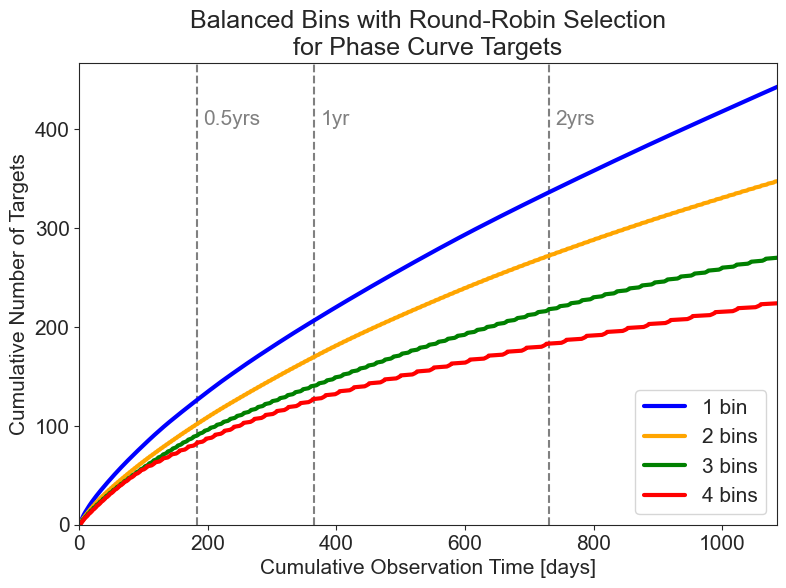

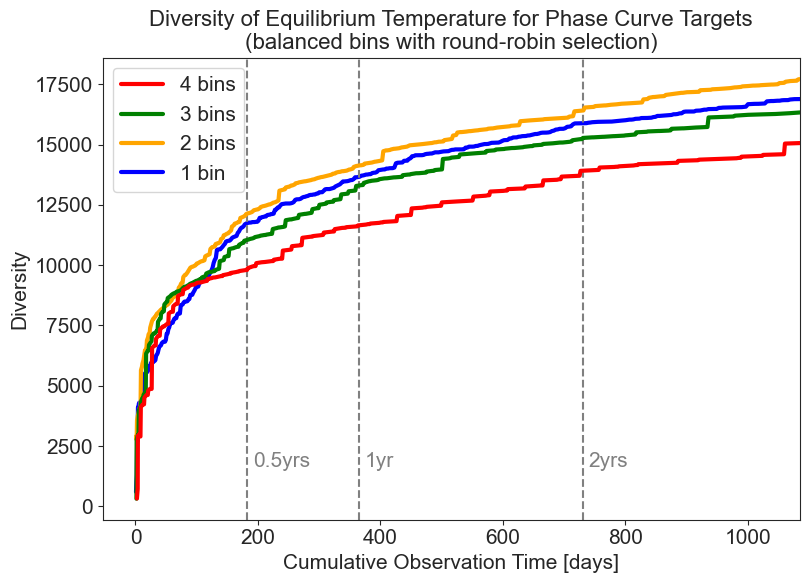

In [369]:
# BALANCED BINS

c1, c2, c3, c4 = "blue", "orange", "green", "red"

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 3*365

bin_config = {
    "Dayside Emitting Temperature [K]": 1
}
binneddf1 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    "Dayside Emitting Temperature [K]": 2
}
binneddf2 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    "Dayside Emitting Temperature [K]": 3
}
binneddf3 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    "Dayside Emitting Temperature [K]": 4
}
binneddf4 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

binneddf1_obs = binneddf1[binneddf1[f"Cum Sum {time_col}"] < obs_time]
binneddf2_obs = binneddf2[binneddf2[f"Cum Sum {time_col}"] < obs_time]
binneddf3_obs = binneddf3[binneddf3[f"Cum Sum {time_col}"] < obs_time]
binneddf4_obs = binneddf4[binneddf4[f"Cum Sum {time_col}"] < obs_time]

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 400, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 400, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 400, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs.index, linewidth=3, label="1 bin", c=c1)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs.index, linewidth=3, label="2 bins", c=c2)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs.index, linewidth=3, label="3 bins", c=c3)
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs.index, linewidth=3, label="4 bins", c=c4)

ax.set_xlim(0, obs_time-10)
ax.set_ylim(0)


ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Cumulative Number of Targets", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)

ax.set_title("Balanced Bins with Round-Robin Selection\nfor Phase Curve Targets", fontsize=fontsize+3)

plt.savefig(dirname + "/Phase Curves/Plots/Phase Curve Balanced Bins (on T_eq).png", dpi=300, bbox_inches='tight')

plt.show()


# plotting standard deviation vs time
def getdiversity(df, col):
    for i, _ in df.iterrows():
        # getting all previous rows and the current one
        df_temp = df.iloc[:i+1]
        df.at[i, f"{col} div"] = df_temp[col].std()*df_temp.shape[0]**0.5
        
getdiversity(binneddf1_obs, "Dayside Emitting Temperature [K]")
getdiversity(binneddf2_obs, "Dayside Emitting Temperature [K]")
getdiversity(binneddf3_obs, "Dayside Emitting Temperature [K]")
getdiversity(binneddf4_obs, "Dayside Emitting Temperature [K]")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs["Dayside Emitting Temperature [K] div"], label="4 bins", linewidth=3, zorder=7, c=c4)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs["Dayside Emitting Temperature [K] div"], label="3 bins", linewidth=3, zorder=5, c=c3)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs["Dayside Emitting Temperature [K] div"], label="2 bins", linewidth=3, zorder=3, c=c2)
ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs["Dayside Emitting Temperature [K] div"], label="1 bin", linewidth=3, zorder=1, c=c1)

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 1450, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 1450, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 1450, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')


ax.set_xlim(None, obs_time-10)
# ax.set_ylim(0)

ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Diversity", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)
ax.set_title("Diversity of Equilibrium Temperature for Phase Curve Targets\n(balanced bins with round-robin selection)", fontsize=fontsize+1)
plt.savefig(dirname + "/Phase Curves/Plots/Phase Curve Balanced Bins (on T_eq) Diversity.png", dpi=300, bbox_inches='tight')
plt.show()

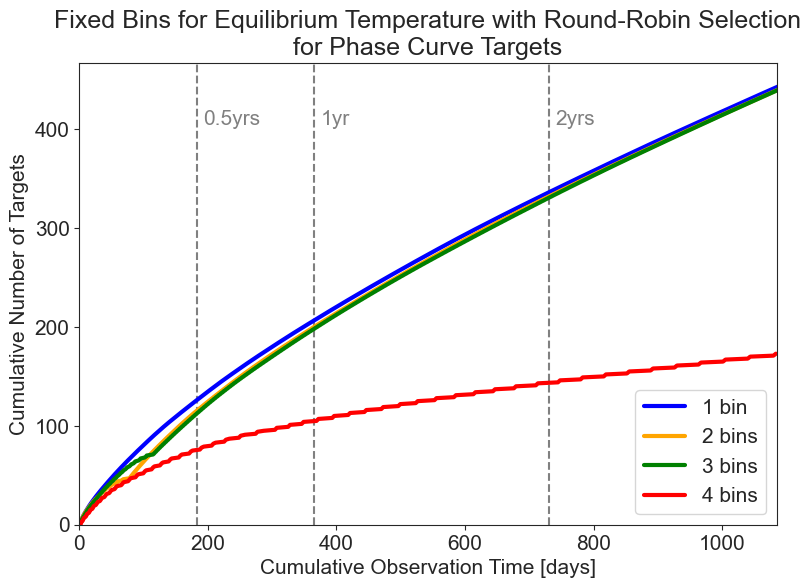

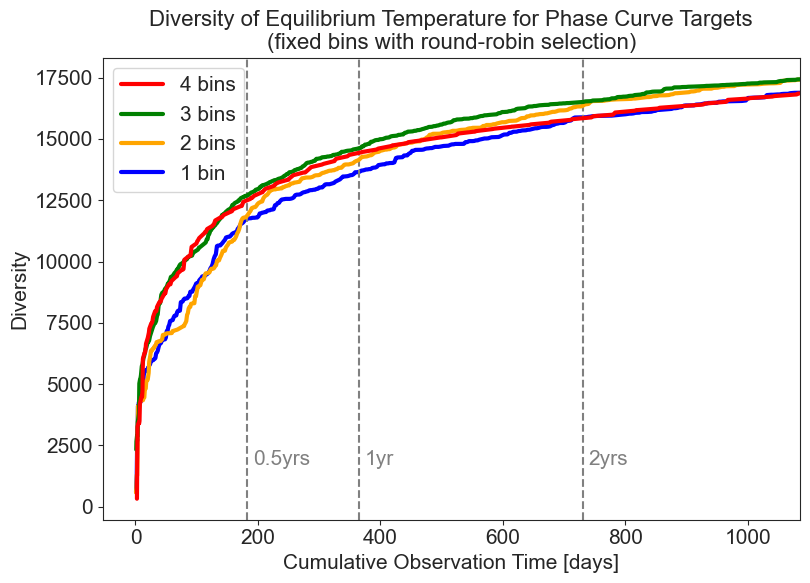

In [368]:
# FIXED BINS

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 3*365

bin_config = {
    "Dayside Emitting Temperature [K]": [0]
}
binneddf1 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    "Dayside Emitting Temperature [K]": [4000]
}

binneddf2 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    "Dayside Emitting Temperature [K]": [2000, 4000]
}
binneddf3 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    "Dayside Emitting Temperature [K]": [1000, 2500, 4000]
}
binneddf4 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)


binneddf1_obs = binneddf1[binneddf1[f"Cum Sum {time_col}"] < obs_time]
binneddf2_obs = binneddf2[binneddf2[f"Cum Sum {time_col}"] < obs_time]
binneddf3_obs = binneddf3[binneddf3[f"Cum Sum {time_col}"] < obs_time]
binneddf4_obs = binneddf4[binneddf4[f"Cum Sum {time_col}"] < obs_time] 

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 400, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 400, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 400, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs.index, linewidth=3, label="1 bin", c=c1)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs.index, linewidth=3, label="2 bins", c=c2)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs.index, linewidth=3, label="3 bins", c=c3)
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs.index, linewidth=3, label="4 bins", c=c4)

ax.set_xlim(0, obs_time-10)
ax.set_ylim(0)


ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Cumulative Number of Targets", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)

ax.set_title("Fixed Bins for Equilibrium Temperature with Round-Robin Selection\nfor Phase Curve Targets", fontsize=fontsize+3)

plt.savefig(dirname + "/Phase Curves/Plots/Phase Curve Fixed Bins (on T_eq).png", dpi=300, bbox_inches='tight')

plt.show()


        
getdiversity(binneddf1_obs, "Dayside Emitting Temperature [K]")
getdiversity(binneddf2_obs, "Dayside Emitting Temperature [K]")
getdiversity(binneddf3_obs, "Dayside Emitting Temperature [K]")
getdiversity(binneddf4_obs, "Dayside Emitting Temperature [K]")


fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs["Dayside Emitting Temperature [K] div"], label="4 bins", linewidth=3, zorder=7, c=c4)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs["Dayside Emitting Temperature [K] div"], label="3 bins", linewidth=3, zorder=5, c=c3)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs["Dayside Emitting Temperature [K] div"], label="2 bins", linewidth=3, zorder=3, c=c2)
ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs["Dayside Emitting Temperature [K] div"], label="1 bin", linewidth=3, zorder=1, c=c1)

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 1550, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 1550, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 1550, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

# ax.axhline(binneddf1["Dayside Emitting Temperature [K]"].std(), color='black', linestyle='--')
# ax.text(373, binneddf1["Dayside Emitting Temperature [K]"].std()+5, "StdDev of all targets", fontsize=fontsize, color='black', ha='left', va='bottom')

ax.set_xlim(None, obs_time-10)
# ax.set_ylim(0)

ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Diversity", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)
ax.set_title("Diversity of Equilibrium Temperature for Phase Curve Targets\n(fixed bins with round-robin selection)", fontsize=fontsize+1)
plt.savefig(dirname + "/Phase Curves/Plots/Phase Curve Fixed Bins (on T_eq) Diversity.png", dpi=300, bbox_inches='tight')
plt.show()

# Bins for transit targets (tier 2)

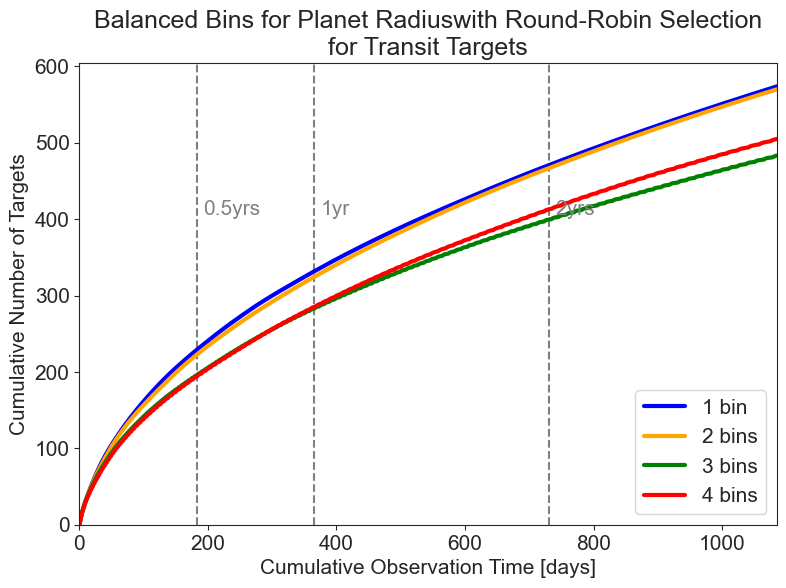

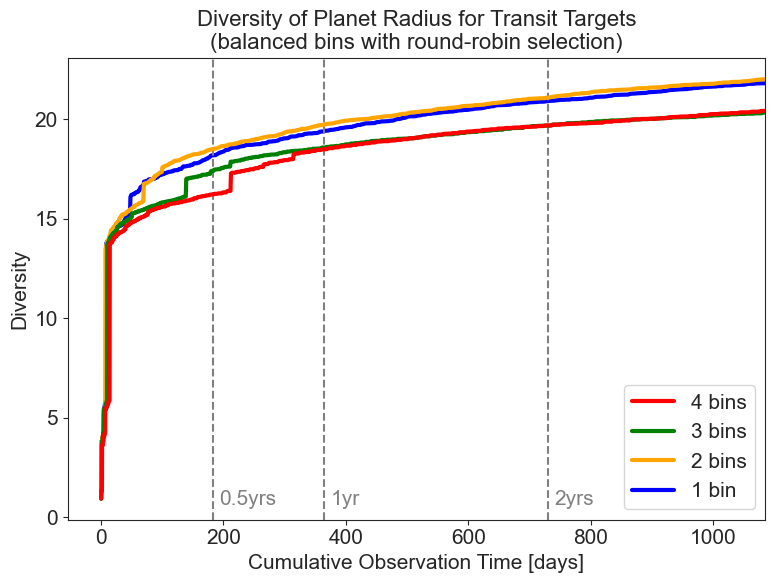

In [370]:
# BALANCED BINS

c1, c2, c3, c4 = "blue", "orange", "green", "red"

time_col = "Time to Tier 2 TSM [days]"
obs_time = 3*365

binned_param = "Planet Radius [Rjup]"

bin_config = {
    binned_param: 1
}
binneddf1 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    binned_param: 2
}
binneddf2 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    binned_param: 3
}
binneddf3 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    binned_param: 4
}
binneddf4 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

binneddf1_obs = binneddf1[binneddf1[f"Cum Sum {time_col}"] < obs_time]
binneddf2_obs = binneddf2[binneddf2[f"Cum Sum {time_col}"] < obs_time]
binneddf3_obs = binneddf3[binneddf3[f"Cum Sum {time_col}"] < obs_time]
binneddf4_obs = binneddf4[binneddf4[f"Cum Sum {time_col}"] < obs_time]

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 400, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 400, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 400, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs.index, linewidth=3, label="1 bin", c=c1)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs.index, linewidth=3, label="2 bins", c=c2)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs.index, linewidth=3, label="3 bins", c=c3)
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs.index, linewidth=3, label="4 bins", c=c4)

ax.set_xlim(0, obs_time-10)
ax.set_ylim(0)


ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Cumulative Number of Targets", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)

ax.set_title("Balanced Bins for Planet Radiuswith Round-Robin Selection\nfor Transit Targets", fontsize=fontsize+3)

plt.savefig(dirname + "/Transits/Plots/Transit Balanced Bins (on R_p).png", dpi=300, bbox_inches='tight')

plt.show()


        
getdiversity(binneddf1_obs, binned_param)
getdiversity(binneddf2_obs, binned_param)
getdiversity(binneddf3_obs, binned_param)
getdiversity(binneddf4_obs, binned_param)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs[f"{binned_param} div"], label="4 bins", linewidth=3, zorder=7, c=c4)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs[f"{binned_param} div"], label="3 bins", linewidth=3, zorder=5, c=c3)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs[f"{binned_param} div"], label="2 bins", linewidth=3, zorder=3, c=c2)
ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs[f"{binned_param} div"], label="1 bin", linewidth=3, zorder=1, c=c1)

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 0.4, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 0.4, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 0.4, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

# ax.axhline(binneddf1[binned_param].std(), color='black', linestyle='--')
# ax.text(373, binneddf1[binned_param].std(), "StdDev of all targets", fontsize=fontsize, color='black', ha='left', va='bottom')

ax.set_xlim(None, obs_time-10)
# ax.set_ylim(0)

ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Diversity", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)
ax.set_title("Diversity of Planet Radius for Transit Targets\n(balanced bins with round-robin selection)", fontsize=fontsize+1)
plt.savefig(dirname + "/Transits/Plots/Transit Balanced Bins (on R_p) Diversity.png", dpi=300, bbox_inches='tight')
plt.show()

In [347]:
for j in range(0, bin_config[binned_param]-1):
        max_param = binneddf2[(binneddf2[f"{binned_param}_bin"] == j)][binned_param].max()
        print(f"Max {binned_param} in bin {j}: {max_param}")
        print(max_param)

Max Planet Radius [Rjup] in bin 0: 1.119
1.119
Max Planet Radius [Rjup] in bin 1: 13.56219264
13.56219264
Max Planet Radius [Rjup] in bin 2: nan
nan


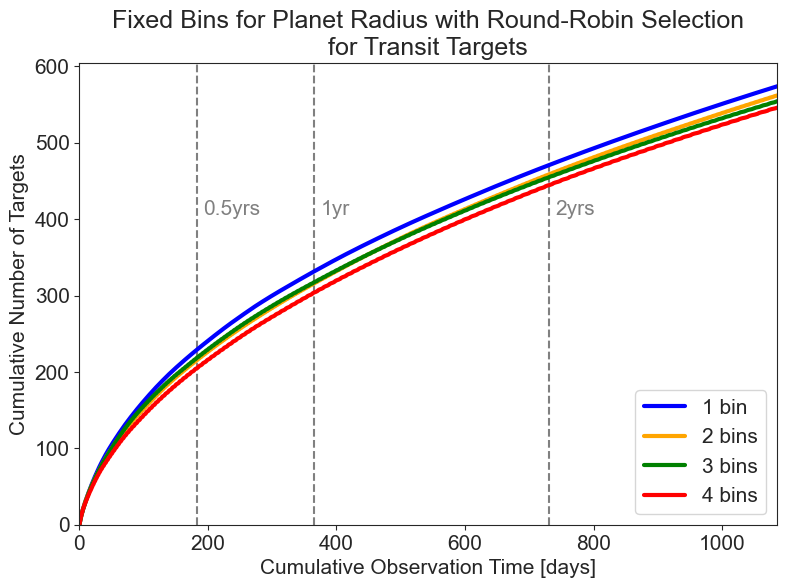

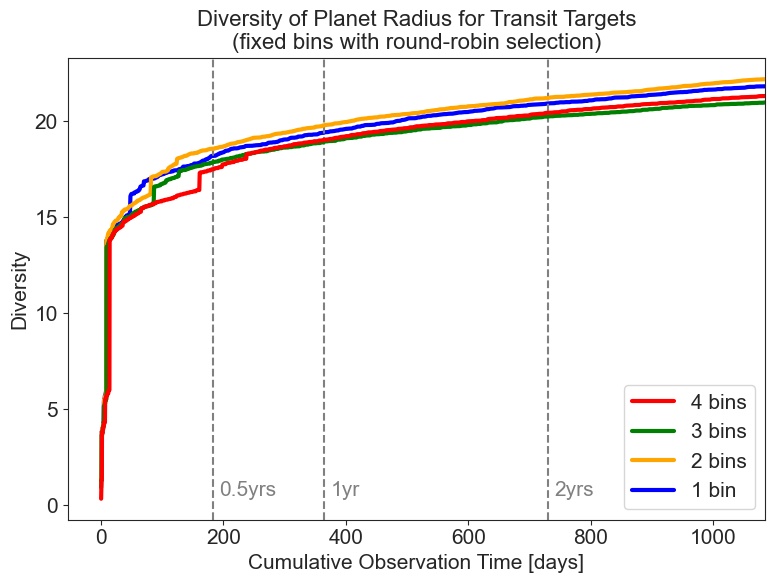

In [371]:
# FIXED BINS

time_col = "Time to Tier 2 TSM [days]"
obs_time = 3*365

binned_param = "Planet Radius [Rjup]"

bin_config = {
    binned_param: [0]
}
binneddf1 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    binned_param: [1]
}

binneddf2 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    binned_param: [1, 1.5]
}
binneddf3 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    binned_param: [0.5, 1, 1.5]
}
binneddf4 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)


binneddf1_obs = binneddf1[binneddf1[f"Cum Sum {time_col}"] < obs_time]
binneddf2_obs = binneddf2[binneddf2[f"Cum Sum {time_col}"] < obs_time]
binneddf3_obs = binneddf3[binneddf3[f"Cum Sum {time_col}"] < obs_time]
binneddf4_obs = binneddf4[binneddf4[f"Cum Sum {time_col}"] < obs_time] 

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 400, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 400, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 400, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs.index, linewidth=3, label="1 bin", c=c1)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs.index, linewidth=3, label="2 bins", c=c2)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs.index, linewidth=3, label="3 bins", c=c3)
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs.index, linewidth=3, label="4 bins", c=c4)

ax.set_xlim(0, obs_time-10)
ax.set_ylim(0)


ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Cumulative Number of Targets", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)

ax.set_title("Fixed Bins for Planet Radius with Round-Robin Selection\nfor Transit Targets", fontsize=fontsize+3)

plt.savefig(dirname + "/Transits/Plots/Transit Fixed Bins (on R_p).png", dpi=300, bbox_inches='tight')

plt.show()

        
getdiversity(binneddf1_obs, binned_param)
getdiversity(binneddf2_obs, binned_param)
getdiversity(binneddf3_obs, binned_param)
getdiversity(binneddf4_obs, binned_param)


fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs[f"{binned_param} div"], label="4 bins", linewidth=3, zorder=7, c=c4)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs[f"{binned_param} div"], label="3 bins", linewidth=3, zorder=5, c=c3)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs[f"{binned_param} div"], label="2 bins", linewidth=3, zorder=3, c=c2)
ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs[f"{binned_param} div"], label="1 bin", linewidth=3, zorder=1, c=c1)

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 0.3, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 0.3, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 0.3, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

# ax.axhline(binneddf1[binned_param].std(), color='black', linestyle='--')
# ax.text(373, binneddf1[binned_param].std(), "StdDev of all targets", fontsize=fontsize, color='black', ha='left', va='bottom')

ax.set_xlim(None, obs_time-10)
# ax.set_ylim(0)

ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Diversity", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)
ax.set_title("Diversity of Planet Radius for Transit Targets\n(fixed bins with round-robin selection)", fontsize=fontsize+1)
plt.savefig(dirname + "/Transits/Plots/Transit Fixed Bins (on R_p) Diversity.png", dpi=300, bbox_inches='tight')
plt.show()

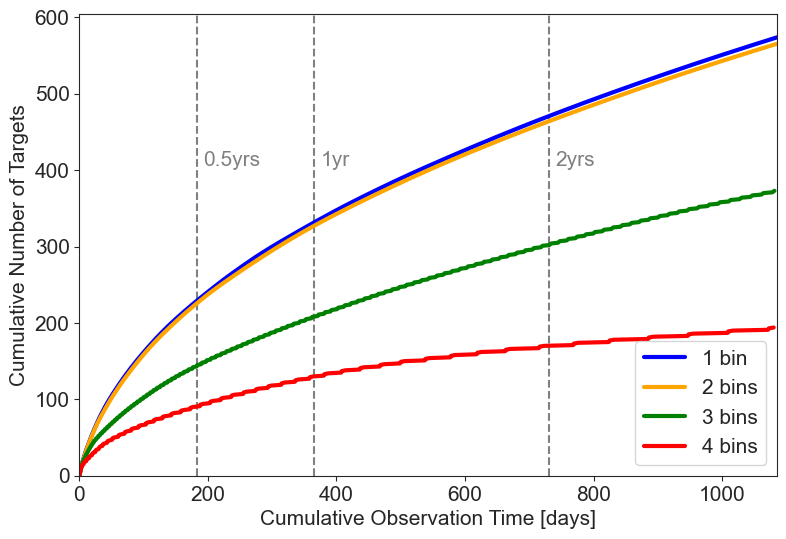

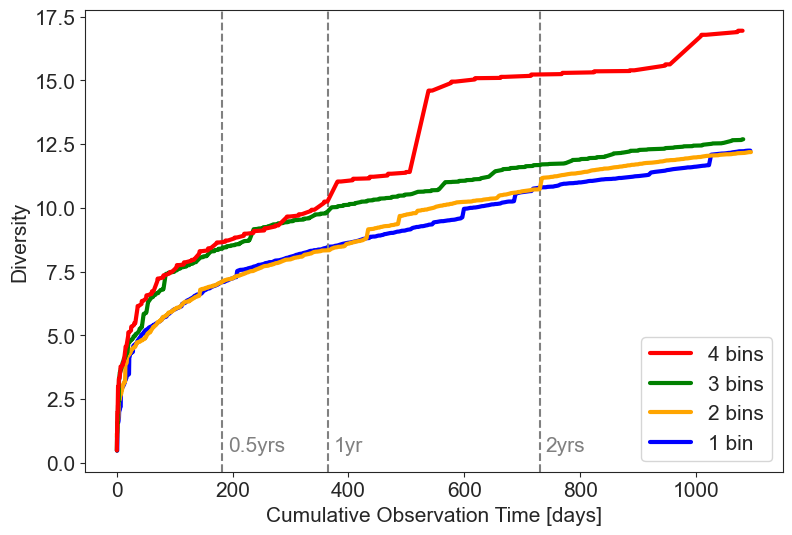

In [437]:
# FIXED BINS

time_col = "Time to Tier 2 TSM [days]"
obs_time = 3*365

binned_param = "Planet Mass [Mjup]"

bin_config = {
    binned_param: [0]
}
binneddf1 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    binned_param: [0.8]
}

binneddf2 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    binned_param: [0.5, 1.2]
}
binneddf3 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)

bin_config = {
    binned_param: [0.5, 1.2, 1.7]
}
binneddf4 = create_fixed_bins(obsdf, bin_config, sort_column=time_col, ascending=True, time_column=time_col)


binneddf1_obs = binneddf1[binneddf1[f"Cum Sum {time_col}"] < obs_time]
binneddf2_obs = binneddf2[binneddf2[f"Cum Sum {time_col}"] < obs_time]
binneddf3_obs = binneddf3[binneddf3[f"Cum Sum {time_col}"] < obs_time]
binneddf4_obs = binneddf4[binneddf4[f"Cum Sum {time_col}"] < obs_time] 

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 400, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 400, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 400, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs.index, linewidth=3, label="1 bin", c=c1)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs.index, linewidth=3, label="2 bins", c=c2)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs.index, linewidth=3, label="3 bins", c=c3)
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs.index, linewidth=3, label="4 bins", c=c4)

ax.set_xlim(0, obs_time-10)
ax.set_ylim(0)


ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Cumulative Number of Targets", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)

# ax.set_title("Fixed Bins for Planet Mass with Round-Robin Selection\nfor Transit Targets", fontsize=fontsize+3)

# plt.savefig(dirname + "/Transits/Plots/Transit Fixed Bins (on M_p).png", dpi=300, bbox_inches='tight')

plt.show()


        
getdiversity(binneddf1_obs, binned_param)
getdiversity(binneddf2_obs, binned_param)
getdiversity(binneddf3_obs, binned_param)
getdiversity(binneddf4_obs, binned_param)


fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs[f"{binned_param} div"], label="4 bins", linewidth=3, zorder=7, c=c4)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs[f"{binned_param} div"], label="3 bins", linewidth=3, zorder=5, c=c3)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs[f"{binned_param} div"], label="2 bins", linewidth=3, zorder=3, c=c2)
ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs[f"{binned_param} div"], label="1 bin", linewidth=3, zorder=1, c=c1)

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 0.3, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 0.3, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 0.3, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

# ax.axhline(binneddf1[binned_param].std(), color='black', linestyle='--')
# ax.text(373, binneddf1[binned_param].std(), "StdDev of all targets", fontsize=fontsize, color='black', ha='left', va='bottom')

# ax.set_xlim(None, obs_time-10)
# ax.set_ylim(0)

ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Diversity", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)
# ax.set_title("Diversity of Planet Mass for Transit Targets\n(fixed bins with round-robin selection)", fontsize=fontsize+1)
# plt.savefig(dirname + "/Transits/Plots/Transit Fixed Bins (on M_p) Diversity.png", dpi=300, bbox_inches='tight')
plt.show()

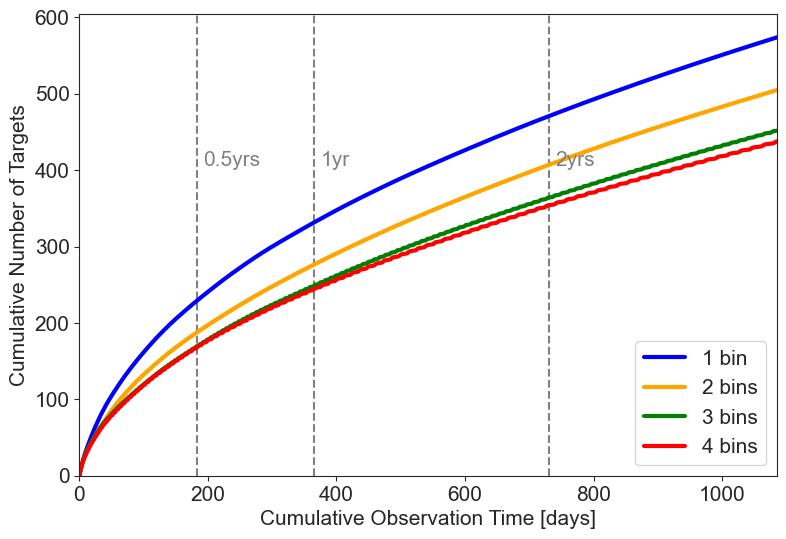

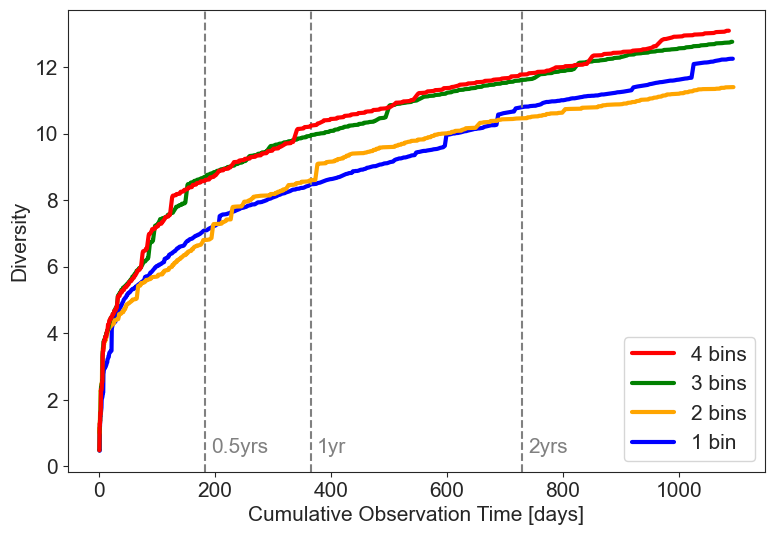

In [438]:
# Balanced BINS

time_col = "Time to Tier 2 TSM [days]"
obs_time = 3*365

binned_param = "Planet Mass [Mjup]"

bin_config = {
    binned_param: 1
}
binneddf1 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    binned_param: 2
}

binneddf2 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    binned_param: 3
}
binneddf3 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)

bin_config = {
    binned_param: 4
}
binneddf4 = create_balanced_bins(obsdf, bin_config, sort_column=time_col, ascending=True, cumulative_sum_column=time_col)


binneddf1_obs = binneddf1[binneddf1[f"Cum Sum {time_col}"] < obs_time]
binneddf2_obs = binneddf2[binneddf2[f"Cum Sum {time_col}"] < obs_time]
binneddf3_obs = binneddf3[binneddf3[f"Cum Sum {time_col}"] < obs_time]
binneddf4_obs = binneddf4[binneddf4[f"Cum Sum {time_col}"] < obs_time] 

fig, ax = plt.subplots(figsize=(9, 6))

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 400, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 400, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 400, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs.index, linewidth=3, label="1 bin", c=c1)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs.index, linewidth=3, label="2 bins", c=c2)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs.index, linewidth=3, label="3 bins", c=c3)
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs.index, linewidth=3, label="4 bins", c=c4)

ax.set_xlim(0, obs_time-10)
ax.set_ylim(0)


ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Cumulative Number of Targets", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)

# ax.set_title("Balanced Bins for Planet Mass with Round-Robin Selection\nfor Transit Targets", fontsize=fontsize+3)

# plt.savefig(dirname + "/Transits/Plots/Transit Balanced Bins (on M_p).png", dpi=300, bbox_inches='tight')

plt.show()


        
getdiversity(binneddf1_obs, binned_param)
getdiversity(binneddf2_obs, binned_param)
getdiversity(binneddf3_obs, binned_param)
getdiversity(binneddf4_obs, binned_param)


fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(binneddf4_obs[f"Cum Sum {time_col}"], binneddf4_obs[f"{binned_param} div"], label="4 bins", linewidth=3, zorder=7, c=c4)
ax.plot(binneddf3_obs[f"Cum Sum {time_col}"], binneddf3_obs[f"{binned_param} div"], label="3 bins", linewidth=3, zorder=5, c=c3)
ax.plot(binneddf2_obs[f"Cum Sum {time_col}"], binneddf2_obs[f"{binned_param} div"], label="2 bins", linewidth=3, zorder=3, c=c2)
ax.plot(binneddf1_obs[f"Cum Sum {time_col}"], binneddf1_obs[f"{binned_param} div"], label="1 bin", linewidth=3, zorder=1, c=c1)

ax.axvline(365/2, color='grey', linestyle='--')
ax.axvline(1*365, color='grey', linestyle='--')
ax.axvline(2*365, color='grey', linestyle='--')
ax.text(365/2+10, 0.3, "0.5yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(1*365+10, 0.3, "1yr", fontsize=fontsize, color='grey', ha='left', va='bottom')
ax.text(2*365+10, 0.3, "2yrs", fontsize=fontsize, color='grey', ha='left', va='bottom')

# ax.axhline(binneddf1[binned_param].std(), color='black', linestyle='--')
# ax.text(373, binneddf1[binned_param].std(), "StdDev of all targets", fontsize=fontsize, color='black', ha='left', va='bottom')

# ax.set_xlim(None, obs_time-10)
# ax.set_ylim(0)

ax.set_xlabel("Cumulative Observation Time [days]", fontsize=fontsize)
ax.set_ylabel("Diversity", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.legend(fontsize=fontsize)
# ax.set_title("Diversity of Planet Mass for Transit Targets\n(balanced bins with round-robin selection)", fontsize=fontsize+1)
# plt.savefig(dirname + "/Transits/Plots/Transit Balanced Bins (on M_p) Diversity.png", dpi=300, bbox_inches='tight')
plt.show()

In [379]:
obsdf.shape[0]

2747

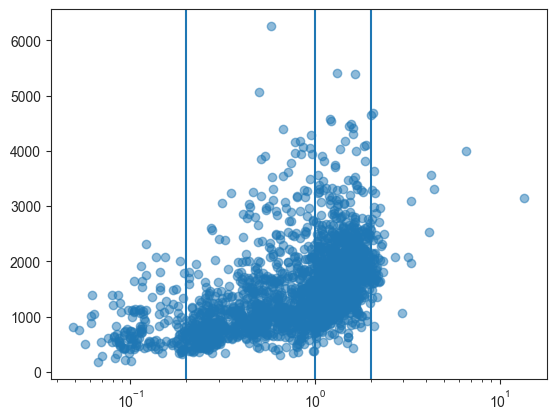

In [240]:
plt.scatter(obsdf["Planet Radius [Rjup]"], obsdf["Dayside Emitting Temperature [K]"], alpha=0.5)
plt.xscale('log')
plt.axvline(1)
plt.axvline(2)
plt.axvline(0.2)

# Bin Animations

In [308]:
def balanced_animation(df, 
                       bin_config, 
                       x_col, 
                       y_col, 
                       sort_column, 
                       time_column=None, 
                       ascending=True,
                       animation_time=365, 
                       directory='ARIEL PC animations', 
                       filename=None,
                       title_params:dict=None, # e.g., title_params = {"Td": ("Dayside Emitting Temperature [K]", "K"), "g": ("Planet Surface Gravity [ms^-2]", "Ms"), "P": ("Planet Period [days]", "days")}
                       figsize=(6, 6),
                       fontsize=12,
                       xscale='log',
                       yscale='linear'
                       ): 
    # create a static jointplot for all targets
    sns.set_style("ticks")
    sns.despine()
    
    x_colbin = f"{x_col}_bin"
    y_colbin = f"{y_col}_bin"
    
    if time_column is None:
        time_column = sort_column

    g = sns.jointplot(data=df, 
                    x=x_col, 
                    y=y_col, 
                    color='gray', 
                    marginal_kws={'kde': True}, 
                    label="All Targets",
                    alpha=0.5)

    g.set_axis_labels(x_col, y_col, fontsize=fontsize)

    # getting figure and axes
    fig = g.figure
    ax = g.ax_joint
    margex = g.ax_marg_x
    margey = g.ax_marg_y
    
    fig.set_figheight(figsize[1])
    fig.set_figwidth(figsize[0])
    
    fig.set_tight_layout(True)

    # setting xscale
    ax.set_xscale(xscale)
    margex.set_xscale(xscale)
    
    # setting yscale
    ax.set_yscale(yscale)
    margey.set_yscale(yscale)
    

    # fixing the limits of the axes
    ax.set_xlim(ax.get_xlim())
    ax.set_ylim(ax.get_ylim())
    ax.minorticks_on()
    margex.minorticks_on()
    margey.minorticks_on()

    # getting the data for the balanced bins
    ordered_df = create_balanced_bins(df, bin_config=bin_config, sort_column=sort_column, cumulative_sum_column=time_column, ascending=ascending)

    # placing horizontal and vertical lines for fixed bins, given by the delimitations above
    for j in range(0, bin_config[y_col]-1):
        max_param = ordered_df[(ordered_df[y_colbin] == j)][y_col].max()
        plt.axhline(max_param, color='black', linestyle='--', linewidth=1, zorder=3)

    for i in range(0, bin_config[x_col]-1):
        max_param = ordered_df[ordered_df[x_colbin] == i][x_col].max()
        plt.axvline(max_param, color='black', linestyle='--', linewidth=1, zorder=3)

    # initializing the scatter plot for the observed targets
    observed_scatter = ax.scatter([], [], marker='o', c='blue', label="Observed Targets", alpha=0.7)

    # getting the number of frames for the animation
    nframes = ordered_df[ordered_df[f"Cum Sum {time_col}"] < animation_time].shape[0]

    # legend
    ax.legend(fontsize=fontsize)

    # removing ticks from marginal axes
    margex.tick_params(labelleft=False, labelbottom=False)
    margey.tick_params(labelleft=False, labelbottom=False)
    
    # changing the fontsize of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    

    # function to update the marginal axes
    def update_marginals(i):
        margex.clear()
        margey.clear()
        
        # replot the background distribution in gray on the marginal axes
        sns.kdeplot(
            data=df,
            x=x_col,
            ax=margex,
            color="gray",
            fill=True,
            alpha=0.2,
            log_scale=True)
        sns.kdeplot(
            data=df,
            y=y_col,
            ax=margey,
            color="gray",
            fill=True,
            alpha=0.2)
        
        # plot the marginal distribution of the observed targets, and normalize it such that the area under the curve is proportional to the number of observed targets
        subset = ordered_df.iloc[:i]
        if len(subset) > 1:
            sns.kdeplot(
                x=subset[x_col],
                ax=margex,
                color="blue",
                fill=True,
                alpha=0.3)
            sns.kdeplot(
                y=subset[y_col],
                ax=margey,
                color="blue",
                fill=True,
                alpha=0.3)
            


    def animate(i):
        print(f"{i} / {nframes}", end='\r')

        x = ordered_df[x_col].iloc[:i]
        y = ordered_df[y_col].iloc[:i]
        
        # updating the scatter plot for the observed targets (using set_offsets to avoid creating a new scatter plot)
        observed_scatter.set_offsets(np.column_stack([x, y]))
        
        update_marginals(i)
        
        # update the title of the joint axes
        title = f"Targets after {i} selections"
        if title_params is not None:
            for key, value in title_params.items():
                title += f"\nStdev {key} = {ordered_df[value[0]][:i].std():.2f} {value[1]}"
        fig.suptitle(f"{title}", fontsize=fontsize+1)

    ani = FuncAnimation(fig, animate, nframes+1, interval=100, repeat=False, blit=False)

    if filename is None:
        filename = f"Balanced bins {tuple(bin_config.values())}"
        
    # # save the animation as an mp4
    ani.save(f'{directory}/{filename}.mp4', writer='ffmpeg', fps=10, dpi=200)

    plt.show()
    
    return ordered_df

    # ordered_df["Dayside Emitting Temperature [K]"].std(), ordered_df["Star Mass [Ms]"].std(), ordered_df["Planet Period [days]"].std()

<Figure size 640x480 with 0 Axes>

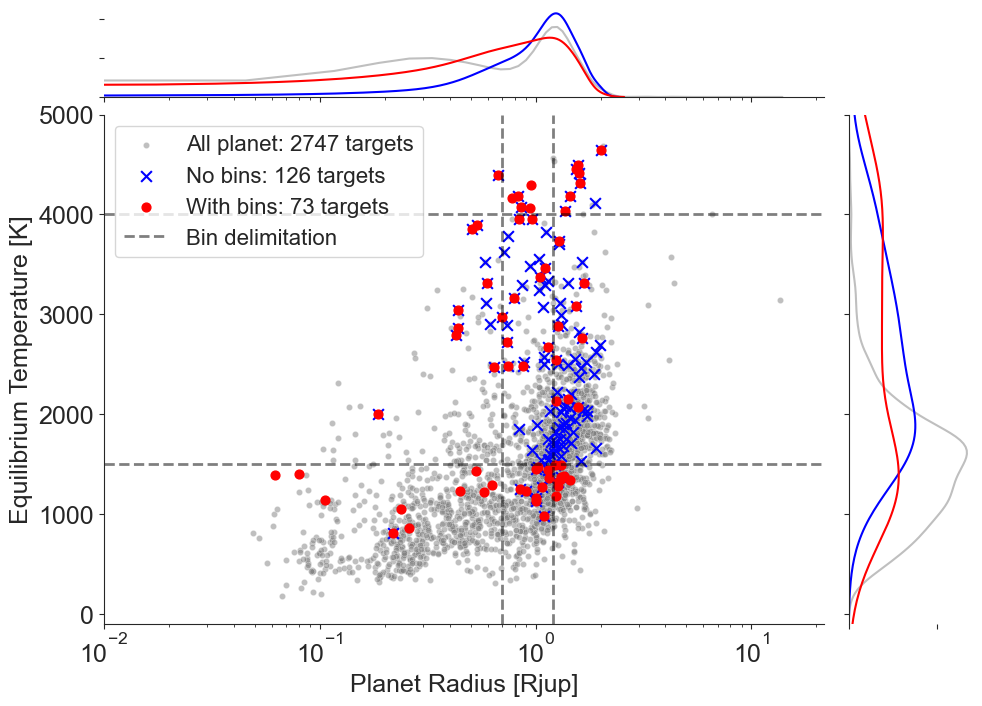

Standard deviation in Dayside Emitting Temperature [K]:  1044.0203056322928 
With 126 targets
Standard deviation in Dayside Emitting Temperature [K] after 1 year:  1381.061989002323 
With 73 targets


In [447]:
x_col = "Planet Radius [Rjup]"
y_col = "Dayside Emitting Temperature [K]"
x_colbin = f"{x_col}_bin"
y_colbin = f"{y_col}_bin"
fontsize = 18

bin_config = {
        "Dayside Emitting Temperature [K]": [1500, 4000],
        "Planet Radius [Rjup]": [0.7, 1.2]
    }

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 365/2

balanced = False
sorted_df = create_fixed_bins(obsdf, bin_config=bin_config, sort_column=time_col, time_column=time_col)
df_1yr = sorted_df[sorted_df["Cum Sum Time to Tier 1 ESM PC [days]"] <= obs_time]

obsdf.sort_values("Time to Tier 1 ESM PC [days]", inplace=True)
obsdf["Cum Sum Time to Tier 1 ESM PC [days]"] =  obsdf["Time to Tier 1 ESM PC [days]"].cumsum()
obs_1yr =  obsdf[ obsdf["Cum Sum Time to Tier 1 ESM PC [days]"] <= obs_time]


# jointplot for all targets
sns.set_style("ticks")
sns.despine()
g = sns.jointplot(obsdf, x=x_col, y=y_col, kind='scatter', s=20, color='gray', alpha=0.5,
                  label=f"All planet: {obsdf.shape[0]} targets")
g.set_axis_labels(x_col, y_col)

# getting axes
fig = g.figure
ax = g.ax_joint
margex = g.ax_marg_x
margey = g.ax_marg_y

# set figsize
fig.set_size_inches(10, 7)

# clearing marginal plots
margex.clear()
margey.clear()

# removing ticks from marginal axes
margex.tick_params(labelleft=False, labelbottom=False)
margey.tick_params(labelleft=False, labelbottom=False)

# plotting marginals for all targets
sns.kdeplot(combined,
            x=x_col,
            ax=margex,
            color="gray",
            alpha=0.5)
sns.kdeplot(combined,
            y=y_col,
            ax=margey,
            color="gray",
            alpha=0.5)

# plotting no bin targets
c = 'blue'
ax.scatter(obs_1yr[x_col], obs_1yr[y_col], marker='x', s=60, label=f"No bins: {obs_1yr.shape[0]} targets", c=c)
sns.kdeplot(obs_1yr, x=x_col, ax=margex, color=c)
sns.kdeplot(obs_1yr, y=y_col, ax=margey, color=c)

# plotting binned targets
c = 'red'
ax.scatter(df_1yr[x_col], df_1yr[y_col], s=40, label=f"With bins: {df_1yr.shape[0]} targets", c=c)
sns.kdeplot(df_1yr, x=x_col, ax=margex, color=c)
sns.kdeplot(df_1yr, y=y_col, ax=margey, color=c)

# plotting bin delimitations
label = "Bin delimitation"
if balanced:
    for j in range(0, bin_config[y_col]-1):
        max_param = sorted_df[(sorted_df[y_colbin] == j)][y_col].max()
        plt.axhline(max_param, color='black', linestyle='--', linewidth=2, label=label, alpha=0.5)
        label = None
        
    for i in range(0, bin_config[x_col]-1):
        max_param = sorted_df[(sorted_df[x_colbin] == i)][x_col].max()
        plt.axvline(max_param, color='black', linestyle='--', linewidth=2, label=label, alpha=0.5)
        label = None
else:
    for j in bin_config[y_col][1:-1]:
        plt.axhline(j, color='black', linestyle='--', linewidth=2, label=label, alpha=0.5)
        label = None
    for i in bin_config[x_col][1:-1]:
        plt.axvline(i, color='black', linestyle='--', linewidth=2, label=label, alpha=0.5)

plt.ylabel("Equilibrium Temperature [K]", fontsize=fontsize)
plt.xlabel(x_col, fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=fontsize)

# fig.suptitle(f"Phase Curve Targets after {obs_time/365:.1f} years with 3 fixed bins for\nEquilibrium Temperature and Planet Radius", fontsize=fontsize+5, y=1.05)

plt.xscale('log')

plt.legend(fontsize=fontsize-2)


plt.xlim(1E-2)
plt.ylim(-100, 5000)

# plt.savefig(f"Phase Curve Binning Plot/{bin_config['Dayside Emitting Temperature [K]']}Td, {bin_config['Planet Period [days]']}P, {bin_config['Planet Surface Gravity [ms^-2]']}g after {obs_time/365:.2f} year ({y_col} vs {x_col}).png",
#             bbox_inches='tight', dpi=300)

plt.show()

# finding the standard deviation in Dayside Emitting Temperature [K]
std =  obs_1yr["Dayside Emitting Temperature [K]"].std()
print("Standard deviation in Dayside Emitting Temperature [K]: ", std, "\nWith",  obs_1yr.shape[0], "targets")

std = df_1yr["Dayside Emitting Temperature [K]"].std()
print("Standard deviation in Dayside Emitting Temperature [K] after 1 year: ", std, "\nWith", df_1yr.shape[0], "targets")

<Figure size 640x480 with 0 Axes>

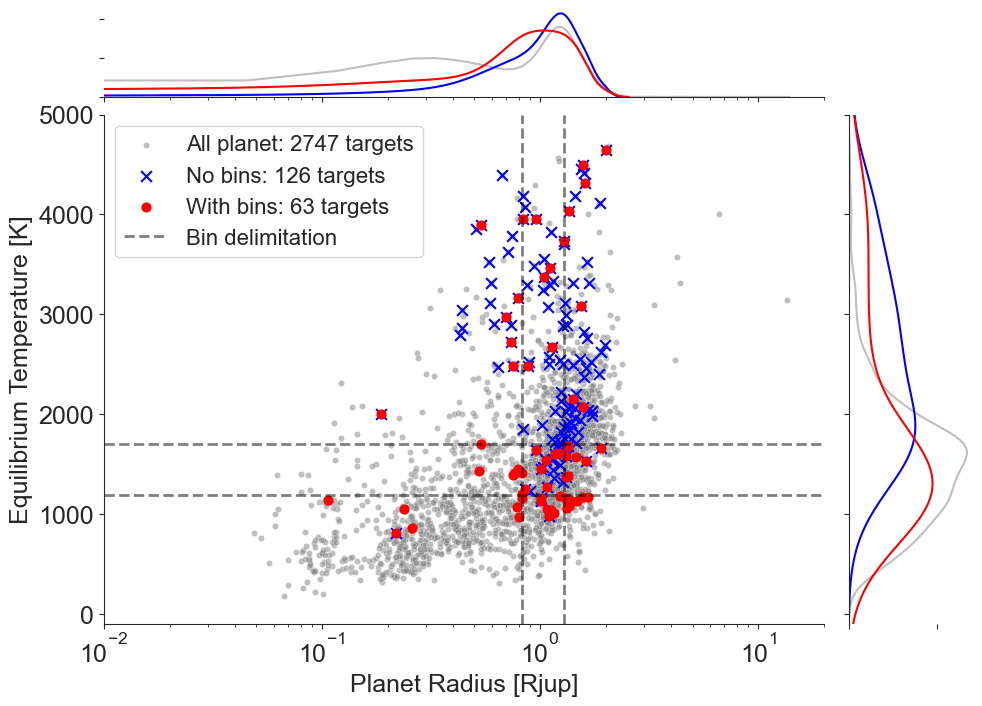

Standard deviation in Dayside Emitting Temperature [K]:  1044.0203056322928 
With 126 targets
Standard deviation in Dayside Emitting Temperature [K] after 1 year:  1194.4691246134546 
With 63 targets


In [445]:
x_col = "Planet Radius [Rjup]"
y_col = "Dayside Emitting Temperature [K]"
x_colbin = f"{x_col}_bin"
y_colbin = f"{y_col}_bin"
fontsize = 18

bin_config = {
        "Dayside Emitting Temperature [K]": 3,
        "Planet Radius [Rjup]": 3
    }

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 365/2

balanced = False
sorted_df = create_balanced_bins(obsdf, bin_config=bin_config, cumulative_sum_column=time_col, sort_column=time_col)
df_1yr = sorted_df[sorted_df["Cum Sum Time to Tier 1 ESM PC [days]"] <= obs_time]

obsdf.sort_values("Time to Tier 1 ESM PC [days]", inplace=True)
obsdf["Cum Sum Time to Tier 1 ESM PC [days]"] =  obsdf["Time to Tier 1 ESM PC [days]"].cumsum()
obs_1yr =  obsdf[ obsdf["Cum Sum Time to Tier 1 ESM PC [days]"] <= obs_time]


# jointplot for all targets
sns.set_style("ticks")
sns.despine()
g = sns.jointplot(obsdf, x=x_col, y=y_col, kind='scatter', s=20, color='gray', alpha=0.5,
                  label=f"All planet: {obsdf.shape[0]} targets")
g.set_axis_labels(x_col, y_col)

# getting axes
fig = g.figure
ax = g.ax_joint
margex = g.ax_marg_x
margey = g.ax_marg_y

# set figsize
fig.set_size_inches(10, 7)

# clearing marginal plots
margex.clear()
margey.clear()

# removing ticks from marginal axes
margex.tick_params(labelleft=False, labelbottom=False)
margey.tick_params(labelleft=False, labelbottom=False)

# plotting marginals for all targets
sns.kdeplot(combined,
            x=x_col,
            ax=margex,
            color="gray",
            alpha=0.5)
sns.kdeplot(combined,
            y=y_col,
            ax=margey,
            color="gray",
            alpha=0.5)

# plotting no bin targets
c = 'blue'
ax.scatter(obs_1yr[x_col], obs_1yr[y_col], marker='x', s=60, label=f"No bins: {obs_1yr.shape[0]} targets", c=c)
sns.kdeplot(obs_1yr, x=x_col, ax=margex, color=c)
sns.kdeplot(obs_1yr, y=y_col, ax=margey, color=c)

# plotting binned targets
c = 'red'
ax.scatter(df_1yr[x_col], df_1yr[y_col], s=40, label=f"With bins: {df_1yr.shape[0]} targets", c=c)
sns.kdeplot(df_1yr, x=x_col, ax=margex, color=c)
sns.kdeplot(df_1yr, y=y_col, ax=margey, color=c)

# plotting bin delimitations
label = "Bin delimitation"
for j in range(0, bin_config[y_col]-1):
    max_param = sorted_df[(sorted_df[y_colbin] == j)][y_col].max()
    plt.axhline(max_param, color='black', linestyle='--', linewidth=2, label=label, alpha=0.5)
    label = None
for i in range(0, bin_config[x_col]-1):
    max_param = sorted_df[sorted_df[x_colbin] == i][x_col].max()
    plt.axvline(max_param, color='black', linestyle='--', linewidth=2, label=label, alpha=0.5)
    label = None

plt.ylabel("Equilibrium Temperature [K]", fontsize=fontsize)
plt.xlabel(x_col, fontsize=fontsize)
plt.tick_params(axis='both', which='major', labelsize=fontsize)

# fig.suptitle(f"Phase Curve Targets after {obs_time/365:.1f} years with 3 fixed bins for\nEquilibrium Temperature and Planet Radius", fontsize=fontsize+5, y=1.05)

plt.xscale('log')

plt.legend(fontsize=fontsize-2)


plt.xlim(1E-2)
plt.ylim(-100, 5000)

# plt.savefig(f"Phase Curve Binning Plot/{bin_config['Dayside Emitting Temperature [K]']}Td, {bin_config['Planet Period [days]']}P, {bin_config['Planet Surface Gravity [ms^-2]']}g after {obs_time/365:.2f} year ({y_col} vs {x_col}).png",
#             bbox_inches='tight', dpi=300)

plt.show()

# finding the standard deviation in Dayside Emitting Temperature [K]
std =  obs_1yr["Dayside Emitting Temperature [K]"].std()
print("Standard deviation in Dayside Emitting Temperature [K]: ", std, "\nWith",  obs_1yr.shape[0], "targets")

std = df_1yr["Dayside Emitting Temperature [K]"].std()
print("Standard deviation in Dayside Emitting Temperature [K] after 1 year: ", std, "\nWith", df_1yr.shape[0], "targets")

<Figure size 640x480 with 0 Axes>

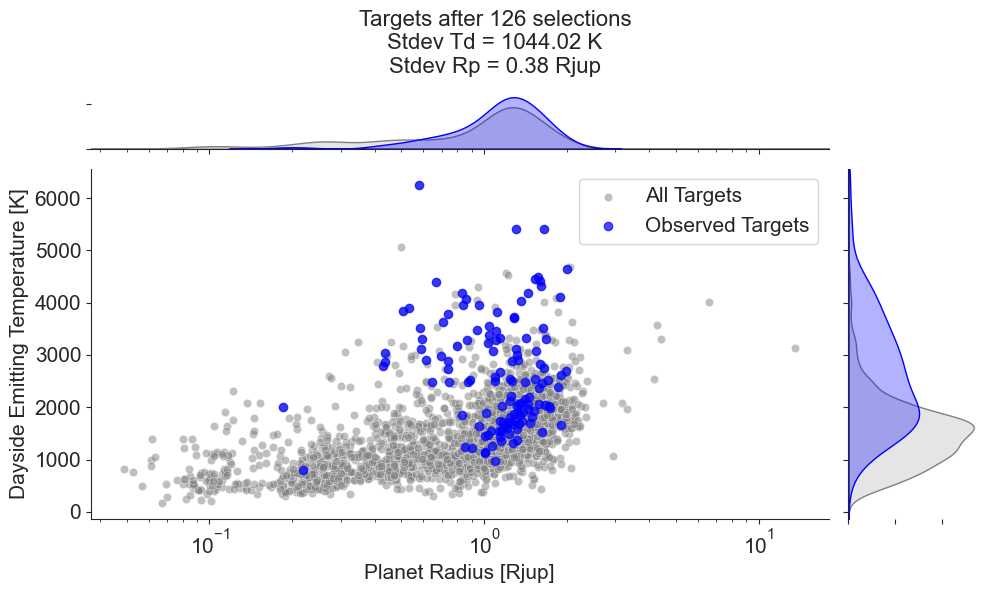

<Figure size 640x480 with 0 Axes>

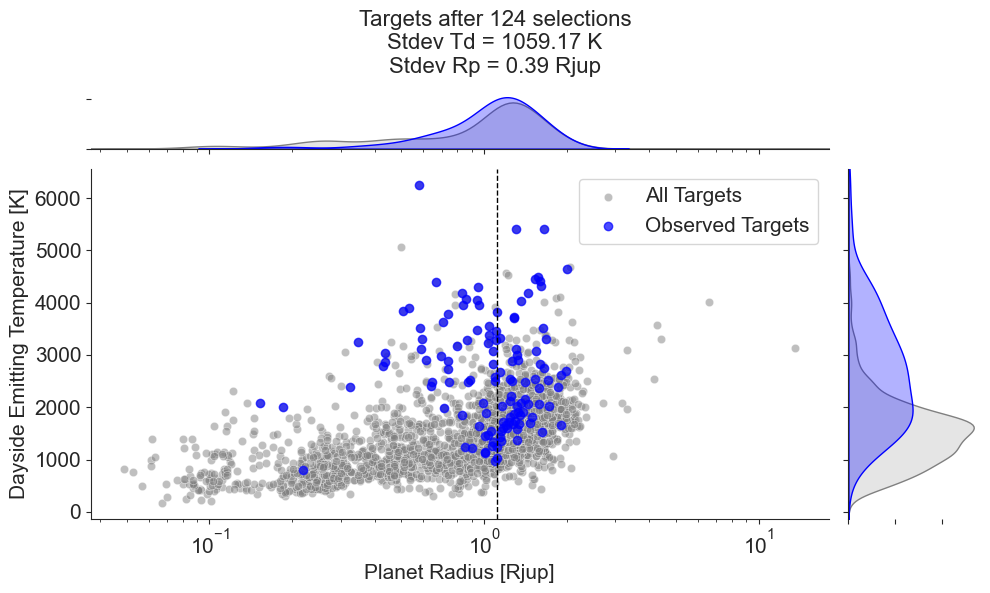

<Figure size 640x480 with 0 Axes>

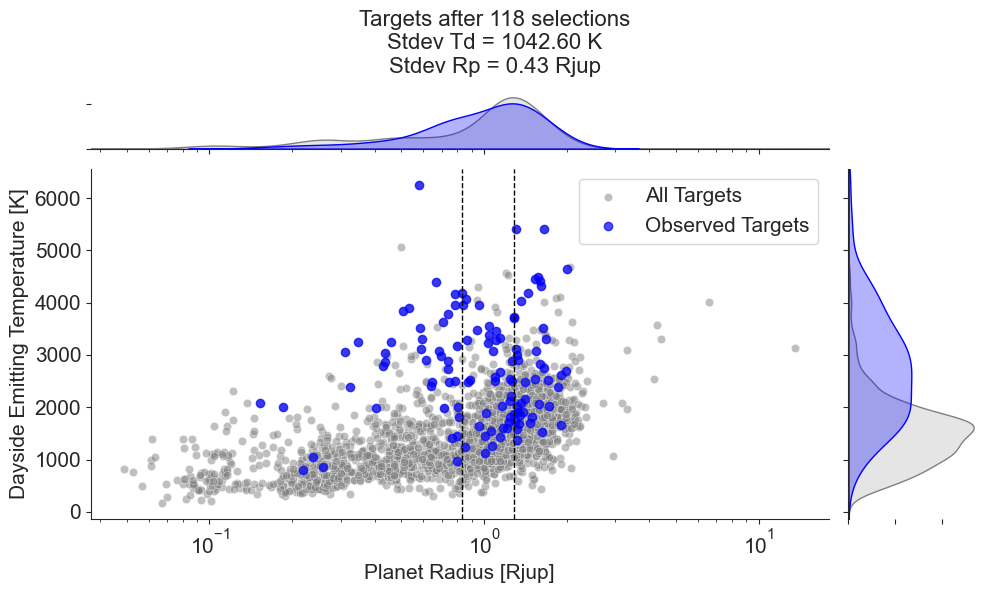

<Figure size 640x480 with 0 Axes>

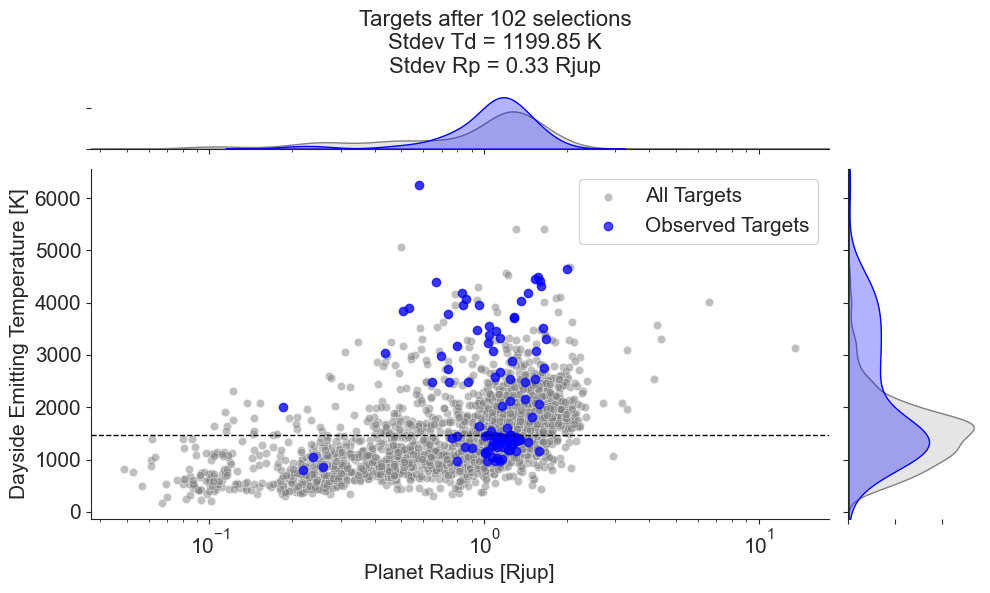

<Figure size 640x480 with 0 Axes>

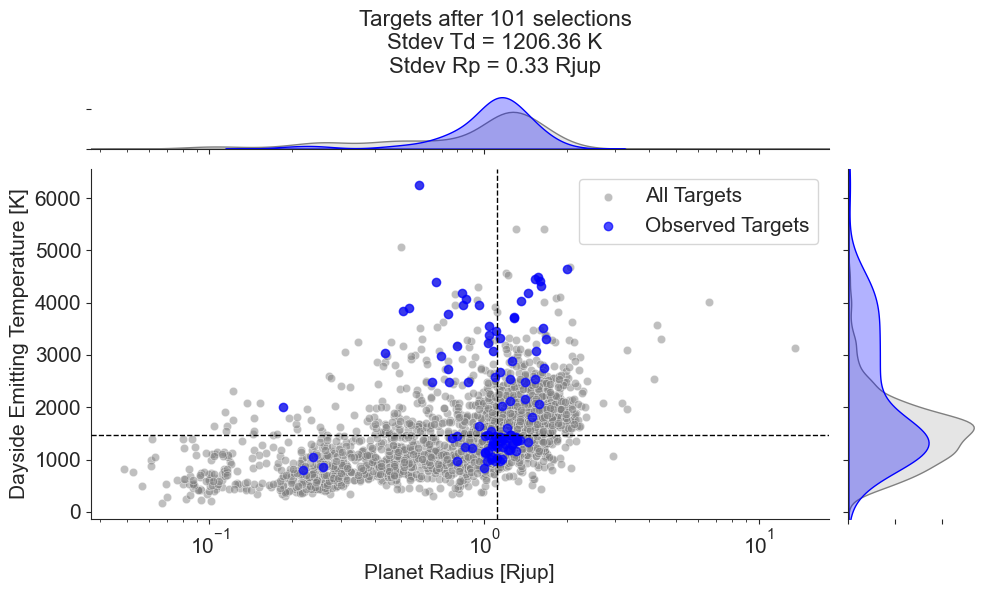

<Figure size 640x480 with 0 Axes>

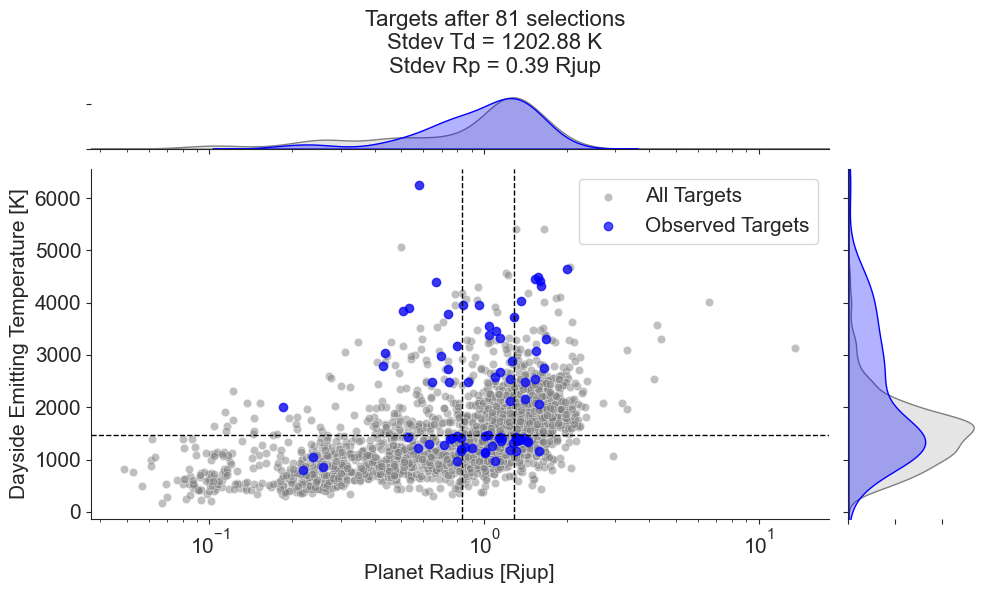

<Figure size 640x480 with 0 Axes>

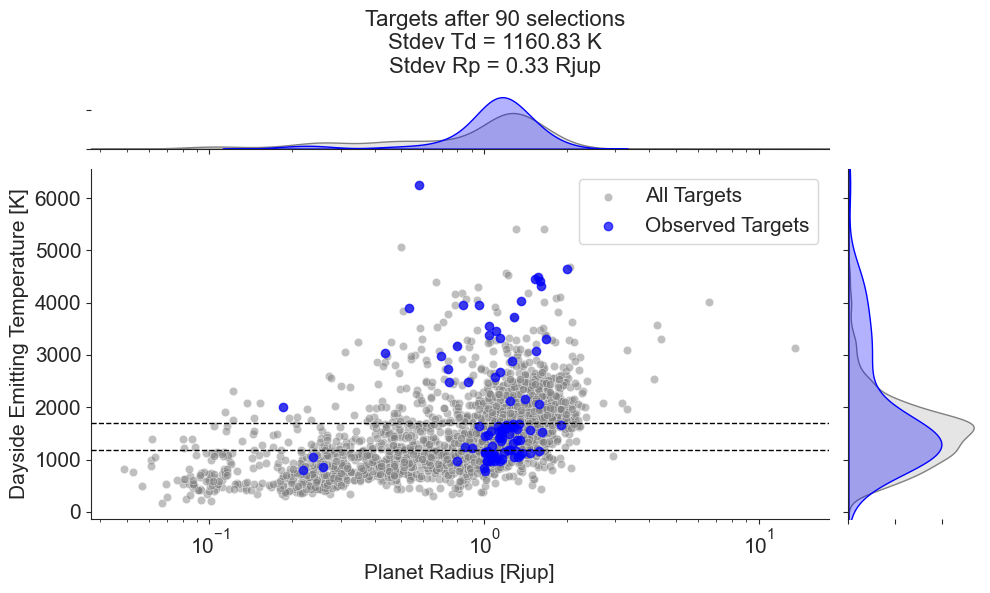

<Figure size 640x480 with 0 Axes>

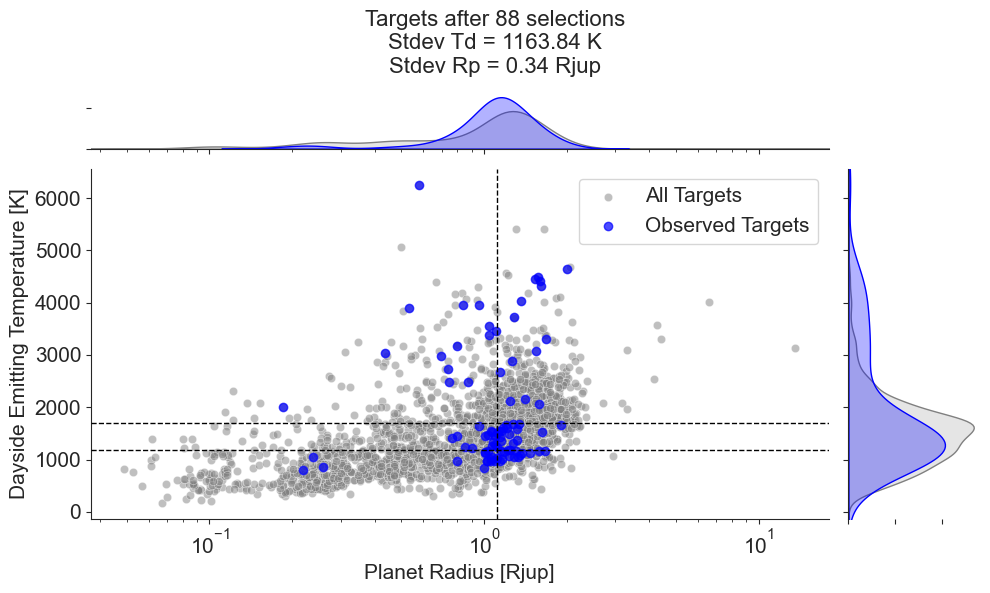

<Figure size 640x480 with 0 Axes>

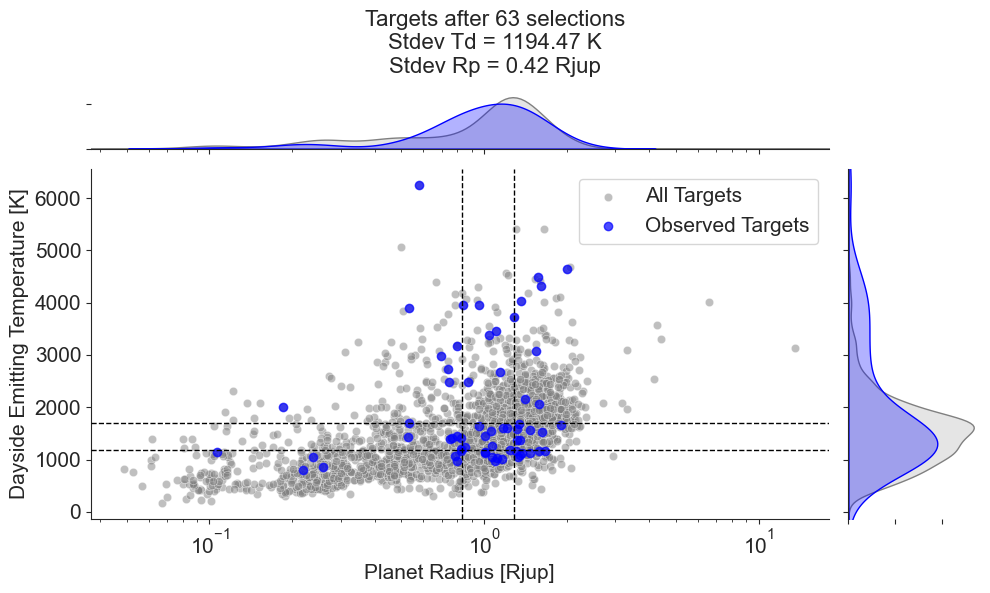

In [298]:
# get (1,1), (1,2), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3)
for i, j in itertools.product(range(1, 4), range(1, 4)):
    bin_config = {
        "Dayside Emitting Temperature [K]": i,
        "Planet Radius [Rjup]": j
    }

    time_col = "Time to Tier 1 ESM PC [days]"
    obs_time = 365/2

    balanced_animation(obsdf, bin_config, 
                    x_col=x_col, 
                    y_col=y_col, 
                    sort_column=time_col, 
                    time_column=time_col, 
                    ascending=True,
                    animation_time=obs_time,
                    directory=dirname + "/Phase Curves/Animations",
                    filename=f"Phase Curve Binning {i} Td, {j} Rp after {obs_time/365:.1f} yrs ({y_col} vs {x_col})",
                    title_params={"Td": ("Dayside Emitting Temperature [K]", "K"), "Rp": ("Planet Radius [Rjup]", "Rjup")},
                    figsize=(10, 6),
                    fontsize=fontsize)

<Figure size 640x480 with 0 Axes>

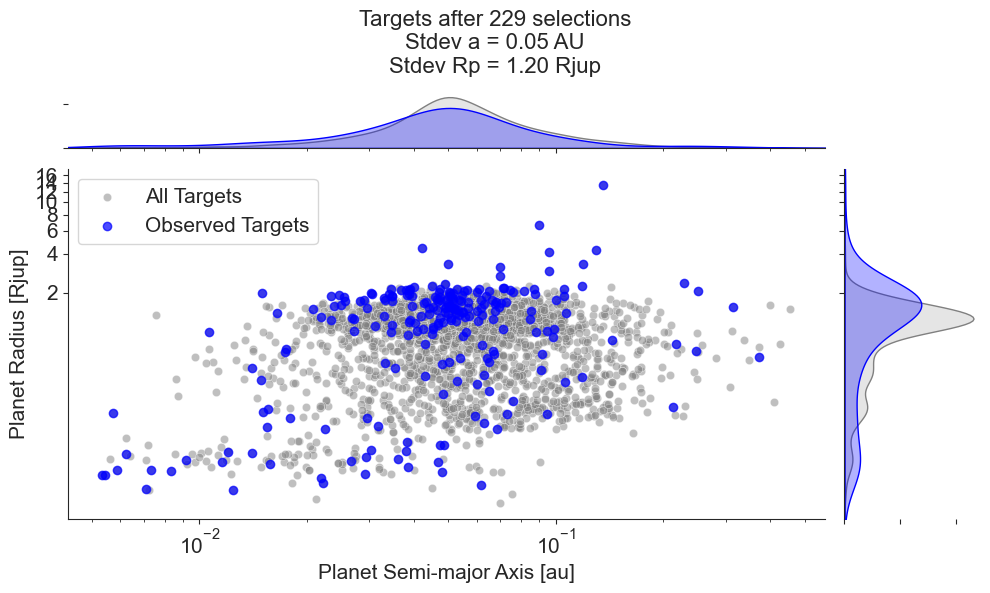

<Figure size 640x480 with 0 Axes>

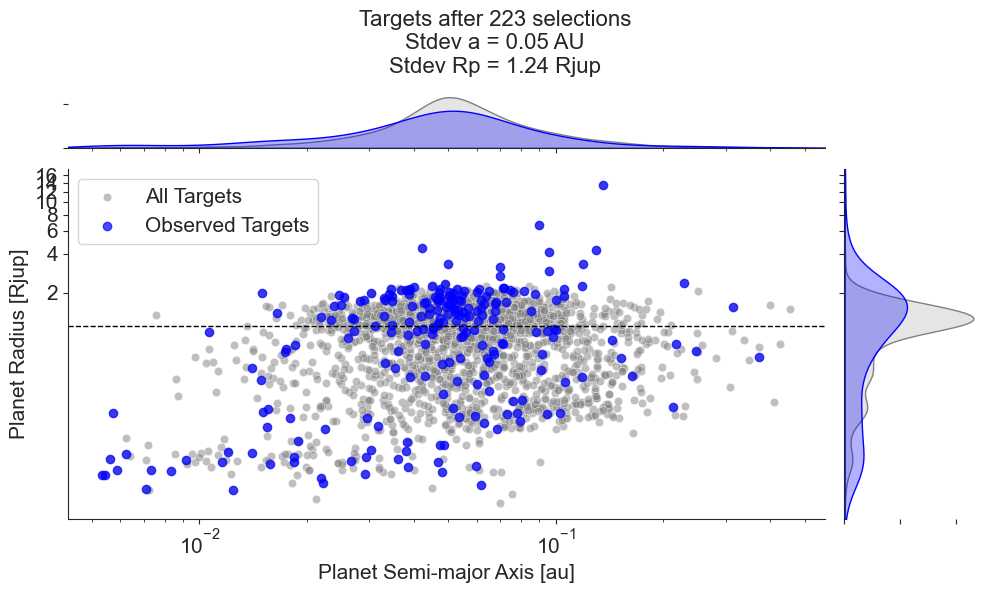

<Figure size 640x480 with 0 Axes>

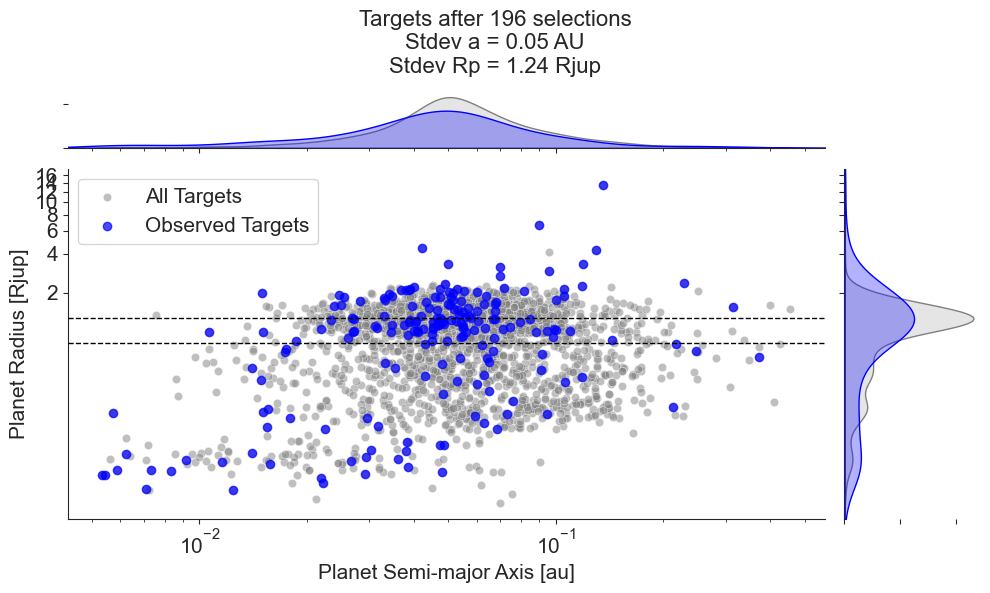

<Figure size 640x480 with 0 Axes>

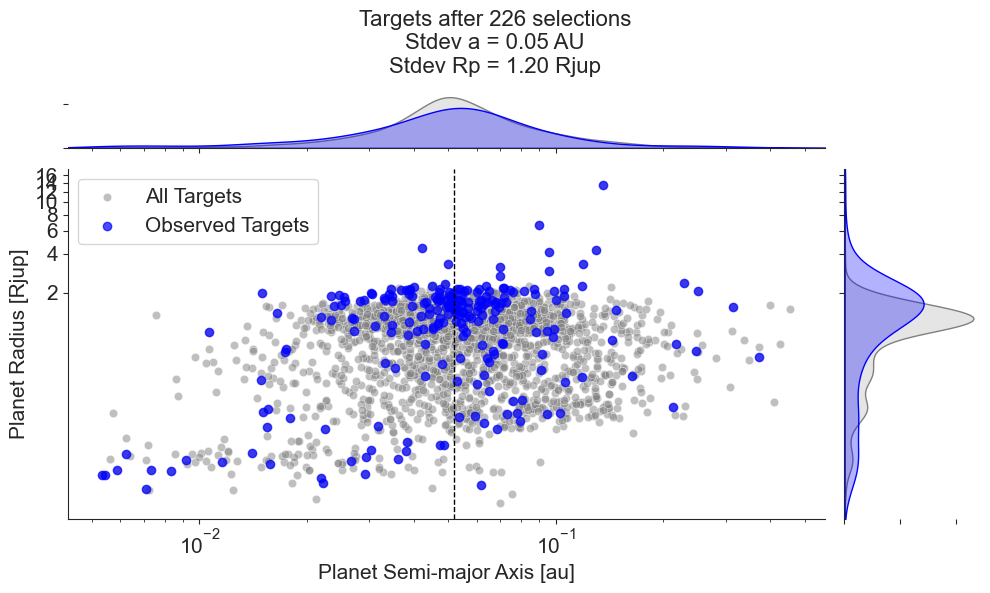

<Figure size 640x480 with 0 Axes>

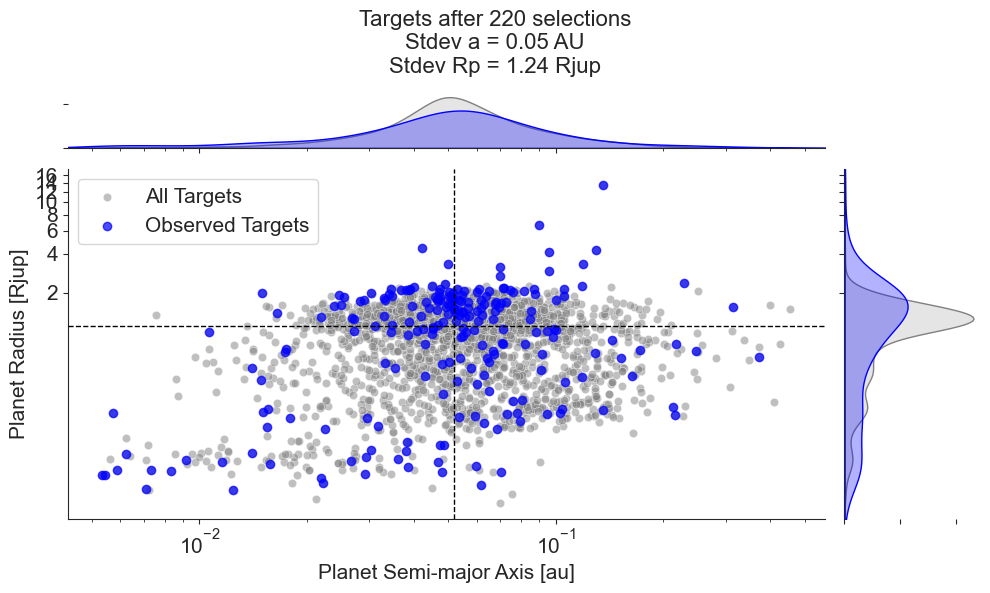

<Figure size 640x480 with 0 Axes>

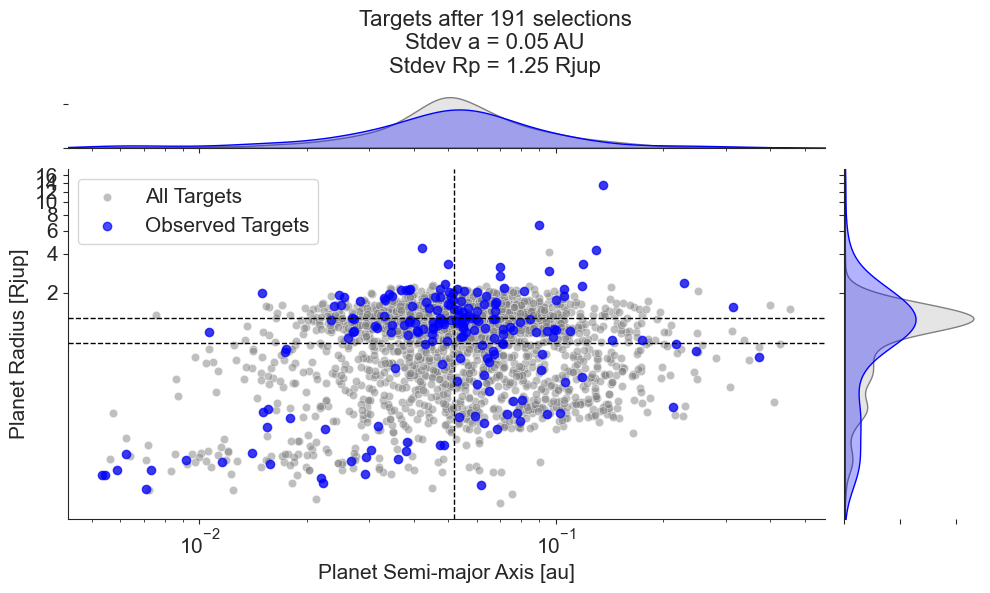

<Figure size 640x480 with 0 Axes>

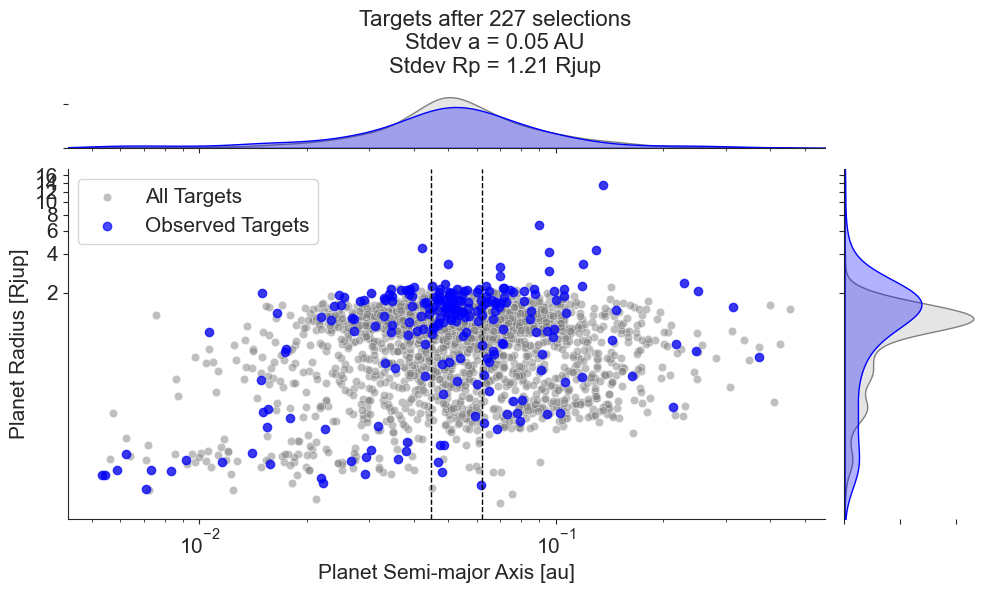

<Figure size 640x480 with 0 Axes>

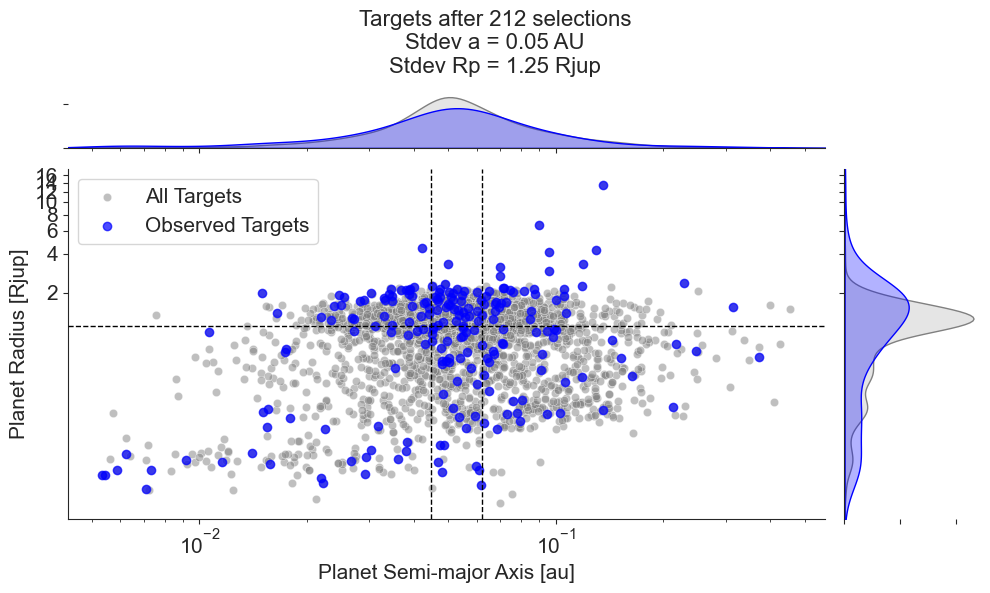

<Figure size 640x480 with 0 Axes>

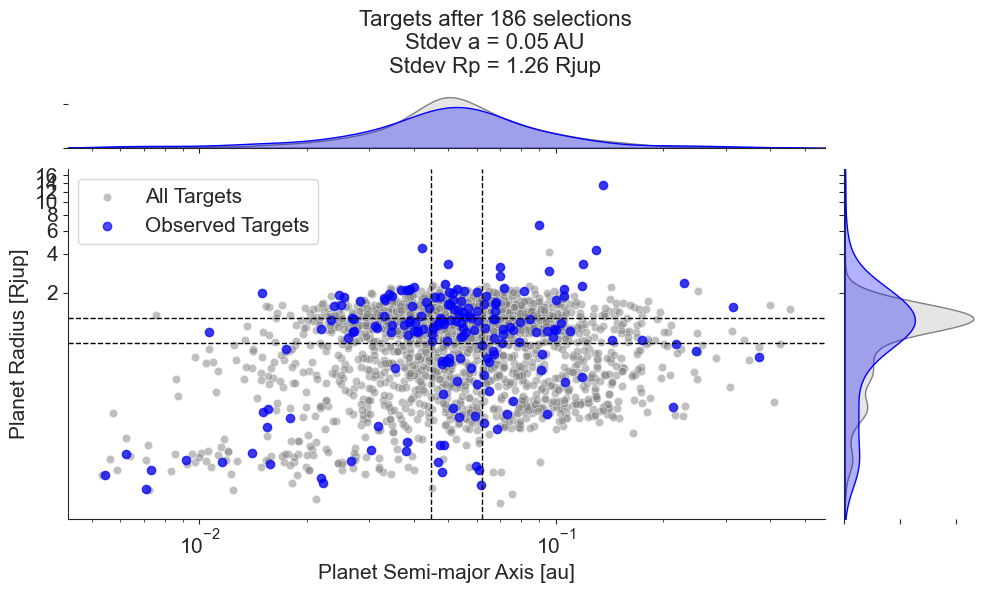

In [309]:
# get (1,1), (1,2), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3)
for i, j in itertools.product(range(1, 4), range(1, 4)):
    bin_config = {
        "Planet Semi-major Axis [au]": i,
        "Planet Radius [Rjup]": j
    }

    time_col = "Time to Tier 2 TSM [days]"
    obs_time = 365/2
    
    x_col = "Planet Semi-major Axis [au]"
    y_col = "Planet Radius [Rjup]"

    balanced_animation(obsdf, bin_config, 
                    x_col=x_col, 
                    y_col=y_col, 
                    sort_column=time_col, 
                    time_column=time_col, 
                    ascending=True,
                    animation_time=obs_time,
                    directory=dirname + "/Transits/Animations",
                    filename=f"Transits Binning {i} a, {j} Rp after {obs_time/365:.1f} yrs ({y_col} vs {x_col})",
                    title_params={"a": ("Planet Semi-major Axis [au]", "AU"), "Rp": ("Planet Radius [Rjup]", "Rjup")},
                    figsize=(10, 6),
                    fontsize=fontsize,
                    xscale='log',
                    yscale='log'
                    )

<Figure size 640x480 with 0 Axes>

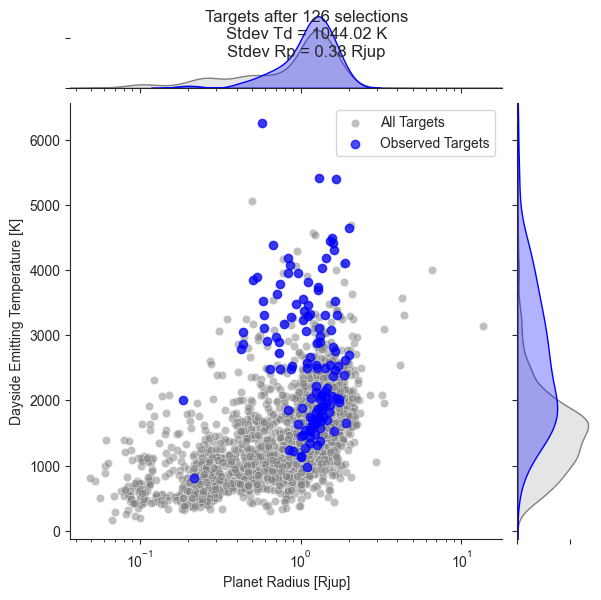

,Star Name,Star Mass [Ms],Star Mass Error Lower [Ms],Star Mass Error Upper [Ms],Star Temperature [K],Star Temperature Error Lower [K],Star Temperature Error Upper [K],Star Radius [Rs],Star Radius Error Lower [Rs],Star Radius Error Upper [Rs],...,Tier 3 Observations Full Phase Curve SNR,Tier 3 Full Phase Curve SNR,log Tier 1 ESM,obs time [days],esm tier 1 diff,Cum Sum obs time [days],Dayside Emitting Temperature [K]_bin,Planet Radius [Rjup]_bin,bin_index,empty_bins
0,TOI-326,0.940,NaN,NaN,5423.9,-152.4,152.4,1.74395,-0.060000,0.060000,...,1.0,11.494502,1.497546,0.309705,0.0,0.309705,0,0,"(0, 0)",0
1,TOI-4274,2.240,NaN,NaN,8878.0,-123.0,123.0,1.70110,NaN,NaN,...,1.0,11.123348,1.544695,0.604180,0.0,0.913885,0,0,"(0, 0)",0
2,TOI-5883,1.230,NaN,NaN,6285.0,-122.9,122.9,1.71813,-0.090000,0.090000,...,8.0,10.345092,0.919054,0.607928,-1.0,1.521813,0,0,"(0, 0)",0
3,TOI-348,1.070,NaN,NaN,5879.0,-124.1,124.1,1.51210,-0.086457,0.086457,...,14.0,10.120829,0.853483,0.612907,-4.0,2.134720,0,0,"(0, 0)",0
4,TOI-1560,2.283,NaN,NaN,9035.0,-204.2,204.2,2.08687,-0.101281,0.101281,...,22.0,10.189226,0.938972,0.649785,-2.0,2.784505,0,0,"(0, 0)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,WASP-14,1.300,-0.06,0.06,6475.0,-100.0,100.0,1.32000,-0.070000,0.100000,...,1.0,15.320782,1.545571,NaN,0.0,NaN,0,0,"(0, 0)",0
2743,WASP-74,0.980,-0.24,0.24,5990.0,-110.0,110.0,1.42000,-0.100000,0.100000,...,1.0,20.915148,1.688819,NaN,0.0,NaN,0,0,"(0, 0)",0
2744,TOI-2109,1.450,-0.07,0.07,6540.0,-160.0,160.0,1.70000,-0.060000,0.060000,...,1.0,18.954563,1.842068,NaN,0.0,NaN,0,0,"(0, 0)",0
2745,TOI-1518,1.790,-0.26,0.26,7300.0,-100.0,100.0,1.95000,-0.050000,0.050000,...,1.0,30.907712,1.884150,NaN,0.0,NaN,0,0,"(0, 0)",0


In [ ]:
bin_config = {
    "Dayside Emitting Temperature [K]": 1,
    "Planet Radius [Rjup]": 1
}

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 365 / 2

balanced_animation(obsdf, bin_config, 
                   x_col=x_col, 
                   y_col=y_col, 
                   sort_column=time_col, 
                   time_column=time_col, 
                   ascending=True,
                   animation_time=obs_time,
                   directory='ARIEL PC animations',
                   filename=f"Phase Curve Binning 1 Td, 1 Rp after {obs_time/365:.1f} yrs ({y_col} vs {x_col})",
                   title_params={"Td": ("Dayside Emitting Temperature [K]", "K"), "Rp": ("Planet Radius [Rjup]", "Rjup")})

<Figure size 640x480 with 0 Axes>

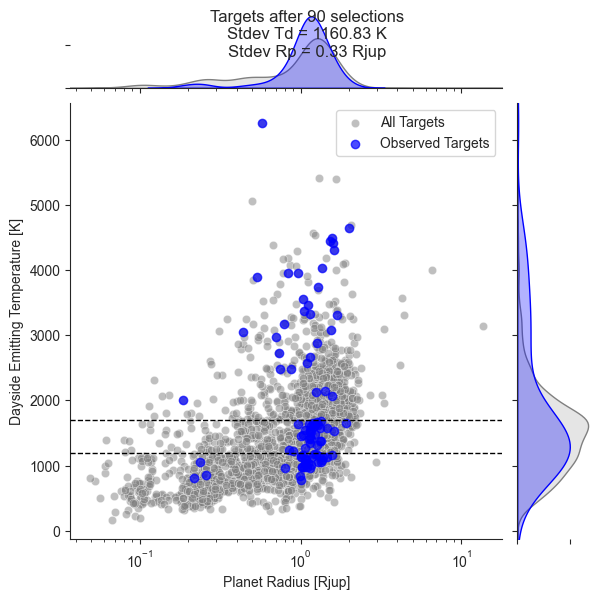

,Star Name,Star Mass [Ms],Star Mass Error Lower [Ms],Star Mass Error Upper [Ms],Star Temperature [K],Star Temperature Error Lower [K],Star Temperature Error Upper [K],Star Radius [Rs],Star Radius Error Lower [Rs],Star Radius Error Upper [Rs],...,Tier 3 Observations Full Phase Curve SNR,Tier 3 Full Phase Curve SNR,log Tier 1 ESM,obs time [days],esm tier 1 diff,Cum Sum obs time [days],Dayside Emitting Temperature [K]_bin,Planet Radius [Rjup]_bin,bin_index,empty_bins
0,TOI-472,0.500534,NaN,NaN,3364.0,NaN,NaN,0.502513,-0.02,0.02,...,1.0,12.100834,1.443127,0.662635,0.0,0.662635,0,0,"(0, 0)",0
1,WASP-43,0.690000,-0.04,0.04,4500.0,-100.0,100.0,0.650000,-0.01,0.01,...,1.0,13.715335,1.500202,0.958974,0.0,1.621609,1,0,"(1, 0)",0
2,TOI-326,0.940000,NaN,NaN,5423.9,-152.4,152.4,1.743950,-0.06,0.06,...,1.0,11.494502,1.497546,0.309705,0.0,1.931314,2,0,"(2, 0)",0
3,TOI-3059,0.400400,NaN,NaN,3301.0,-51.7,51.7,0.445818,NaN,NaN,...,18.0,10.247515,0.860023,1.744722,-2.0,3.676036,0,0,"(0, 0)",0
4,TOI-5681,0.822000,NaN,NaN,4974.0,-126.4,126.4,0.882839,-0.06,0.06,...,8.0,10.312675,0.867385,1.251629,0.0,4.927666,1,0,"(1, 0)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,WASP-98,0.810000,-0.06,0.06,5473.0,-121.0,121.0,0.740000,-0.02,0.02,...,6.0,10.034308,0.938324,NaN,-1.0,NaN,0,0,"(0, 0)",0
2743,HD209458,1.230000,-0.09,0.09,6091.0,-10.0,10.0,1.190000,-0.02,0.02,...,1.0,43.870499,1.921741,NaN,0.0,NaN,1,0,"(1, 0)",0
2744,TOI-2109,1.450000,-0.07,0.07,6540.0,-160.0,160.0,1.700000,-0.06,0.06,...,1.0,18.954563,1.842068,NaN,0.0,NaN,2,0,"(2, 0)",1
2745,TrES-1,1.040000,-0.19,0.19,5230.0,-50.0,50.0,0.850000,-0.05,0.05,...,3.0,10.213219,1.093671,NaN,0.0,NaN,0,0,"(0, 0)",1


In [ ]:
bin_config = {
    "Dayside Emitting Temperature [K]": 3,
    "Planet Radius [Rjup]": 1
}

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 365 / 2

balanced_animation(obsdf, bin_config, 
                   x_col=x_col, 
                   y_col=y_col, 
                   sort_column=time_col, 
                   time_column=time_col, 
                   ascending=True,
                   animation_time=obs_time,
                   directory='ARIEL PC animations',
                   filename=f"Phase Curve Binning 3 Td, 1 Rp after {obs_time/365:.1f} yrs ({y_col} vs {x_col})",
                   title_params={"Td": ("Dayside Emitting Temperature [K]", "K"), "Rp": ("Planet Radius [Rjup]", "Rjup")})

<Figure size 640x480 with 0 Axes>

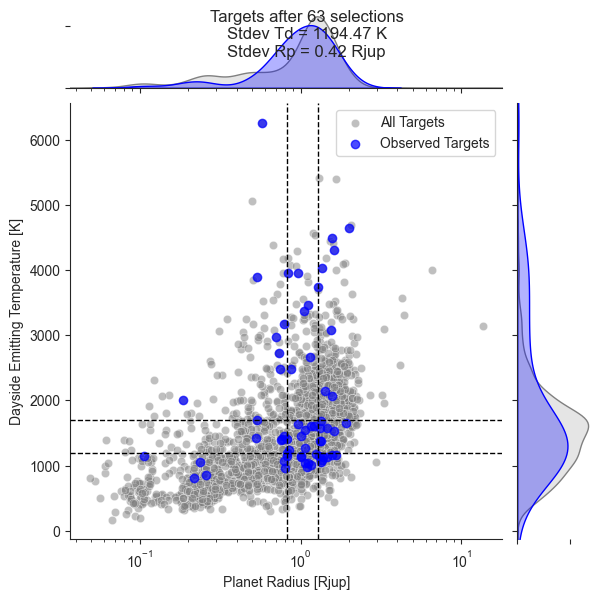

,Star Name,Star Mass [Ms],Star Mass Error Lower [Ms],Star Mass Error Upper [Ms],Star Temperature [K],Star Temperature Error Lower [K],Star Temperature Error Upper [K],Star Radius [Rs],Star Radius Error Lower [Rs],Star Radius Error Upper [Rs],...,Tier 3 Observations Full Phase Curve SNR,Tier 3 Full Phase Curve SNR,log Tier 1 ESM,obs time [days],esm tier 1 diff,Cum Sum obs time [days],Dayside Emitting Temperature [K]_bin,Planet Radius [Rjup]_bin,bin_index,empty_bins
0,TOI-3059,0.400400,NaN,NaN,3301.0,-51.7,51.7,0.445818,NaN,NaN,...,18.0,10.247515,0.860023,1.744722,-2.0,1.744722,0,0,"(0, 0)",0
1,TOI-472,0.500534,NaN,NaN,3364.0,NaN,NaN,0.502513,-0.02,0.02,...,1.0,12.100834,1.443127,0.662635,0.0,2.407357,0,1,"(0, 1)",0
2,TOI-5863,0.783000,NaN,NaN,4829.0,-139.1,139.1,0.865172,-0.06,0.06,...,6.0,10.832336,0.872386,3.080007,0.0,5.487364,0,2,"(0, 2)",0
3,TOI-1194,1.010000,-0.05,0.05,5446.0,-48.0,51.0,0.960000,-0.05,0.06,...,7.0,10.727545,0.845543,2.521144,0.0,8.008508,1,0,"(1, 0)",0
4,WASP-43,0.690000,-0.04,0.04,4500.0,-100.0,100.0,0.650000,-0.01,0.01,...,1.0,13.715335,1.500202,0.958974,0.0,8.967482,1,1,"(1, 1)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,TOI-1685,0.490000,-0.02,0.02,3434.0,-51.0,51.0,0.490000,-0.01,0.01,...,436.0,10.000412,0.856399,NaN,-13.0,NaN,0,0,"(0, 0)",8
2743,LP714-47,0.590000,-0.02,0.02,3950.0,-51.0,51.0,0.580000,-0.02,0.02,...,145.0,10.022170,0.857628,NaN,-1.0,NaN,0,0,"(0, 0)",8
2744,GJ3470,0.510000,-0.06,0.06,3652.0,-50.0,50.0,0.480000,-0.04,0.04,...,88.0,10.043378,0.868740,NaN,0.0,NaN,0,0,"(0, 0)",8
2745,TOI-1694,0.840000,-0.11,0.11,5135.0,-50.0,50.0,0.820000,-0.05,0.05,...,40.0,10.094122,0.872908,NaN,2.0,NaN,0,0,"(0, 0)",8


In [ ]:
bin_config = {
    "Dayside Emitting Temperature [K]": 3,
    "Planet Radius [Rjup]": 3
}

time_col = "Time to Tier 1 ESM PC [days]"
obs_time = 365 / 2

balanced_animation(obsdf, bin_config, 
                   x_col=x_col, 
                   y_col=y_col, 
                   sort_column=time_col, 
                   time_column=time_col, 
                   ascending=True,
                   animation_time=obs_time,
                   directory='ARIEL PC animations',
                   filename=f"Phase Curve Binning 3 Td, 3 Rp after {obs_time/365:.1f} yrs ({y_col} vs {x_col})",
                   title_params={"Td": ("Dayside Emitting Temperature [K]", "K"), "Rp": ("Planet Radius [Rjup]", "Rjup")})